# InfographicVQA Visual Question Answering Benchmark Analysis

Executive Summary

**Dataset:** InfographicVQA_mini - Infographic Visual Question Answering  
**Total Samples:** 500 infographic Q&A pairs per phase  
**Task:** Answer questions about infographic images (charts, statistics, visual design)  
**Evaluation Metrics:** GT in Pred (PRIMARY), ANLS, Exact Match, Substring Match, Cosine Similarity

## Benchmark Structure

### $QA_{\text{OCR}}$: OCR parsing → LLM QA
**Strategy:** Separate OCR extraction → LLM answers question based on extracted text

- **$QA_{\text{OCR}}^{\text{simple}}$:** Azure Intelligence OCR + GPT-5-mini QA (simple prompt)
- **$QA_{\text{OCR}}^{\text{generic}}$:** Mistral OCR 2 OCR + GPT-5-mini QA (generic prompt)
- **$QA_{\text{OCR}}^{\text{task-aware}}$:** Azure Intelligence OCR + GPT-5-mini QA (task-aware prompt)

**Model Format:** `{parsing_model}__{qa_model}` (e.g., `azure_intelligence__gpt-5-mini`)

### $QA_{\text{VLM-2stage}}$: VLM parsing → LLM QA
**Strategy:** Same VLM does both parsing and question answering

- **$QA_{\text{VLM-2stage}}^{\text{cot}}$:** GPT-5-mini does parsing + QA (CoT prompt)
- **$QA_{\text{VLM-2stage}}^{\text{generic+cot}}$:** GPT-5-nano does parsing + QA (generic + CoT)
- **$QA_{\text{VLM-2stage}}^{\text{sonnet}}$:** Claude Sonnet does parsing + QA

**Model Format:** `{model}__{model}` (e.g., `claude_sonnet__claude_sonnet`)

### $QA_{\text{VLM-direct}}$: Direct VLM QA
**Strategy:** VLM sees image directly and answers question

- **$QA_{\text{VLM-direct}}^{\text{sonnet}}$:** Claude Sonnet direct VQA
- **$QA_{\text{VLM-direct}}^{\text{multi}}$:** GPT-5-mini, GPT-5-nano, Claude Sonnet direct VQA

**Model Format:** `{model}` (e.g., `claude_sonnet`)

### $QA_{\text{special}}$: Special Strategy
**Strategy:** Experimental approaches for infographics

- **$QA_{\text{special}}^{a}$:** Special strategy variant A
- **$QA_{\text{special}}^{b}$:** Special strategy variant B
- **$QA_{\text{special}}^{c}$:** Special strategy variant C

# 1. Imports and Metadata

In [1]:
# Required imports
import sys
from pathlib import Path
from typing import List, Dict, Any, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Add parent directories to path for imports
sys.path.insert(0, str(Path("../../../..").resolve()))

# Import metrics functions
from ocr_vs_vlm.metrics.evaluation_metrics import (
    compute_anls,
    compute_exact_match,
    compute_substring_match,
    compute_ground_truth_in_prediction,
    compute_prediction_in_ground_truth,
    parse_ground_truths
)
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Set display options
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.dpi'] = 100

# Color palette for visualizations
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'mistral_ocr_3', 'donut', 
               'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        # Extract base model name (remove __ suffix for QA1/QA2 phases)
        base_model = model.split('__')[-1] if '__' in model else model
        try:
            return MODEL_ORDER.index(base_model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral OCR 2',
        'mistral_ocr_3': 'Mistral OCR 3',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    # Handle composite model names (e.g., azure_intelligence__gpt-5-mini)
    if '__' in model:
        parts = model.split('__')
        return f"{display_names.get(parts[0], parts[0])} → {display_names.get(parts[1], parts[1])}"
    return display_names.get(model, model)

def get_phase_group(phase: str) -> str:
    """Get phase group with formal notation."""
    if phase.startswith('QA1'):
        return '$QA_{\\text{OCR}}$'
    elif phase.startswith('QA2'):
        return '$QA_{\\text{VLM-2stage}}$'
    elif phase.startswith('QA3'):
        return '$QA_{\\text{VLM-direct}}$'
    elif phase.startswith('QA4'):
        return '$QA_{\\text{special}}$'
    return 'Unknown'

def get_phase_formal_name(phase: str) -> str:
    """Get formal mathematical name for a specific phase."""
    phase_mapping = {
        'QA1a': '$QA_{\\text{OCR}}^{\\text{simple}}$',
        'QA1b': '$QA_{\\text{OCR}}^{\\text{generic}}$',
        'QA1c': '$QA_{\\text{OCR}}^{\\text{task-aware}}$',
        'QA2a': '$QA_{\\text{VLM-2stage}}^{\\text{cot}}$',
        'QA2b': '$QA_{\\text{VLM-2stage}}^{\\text{generic+cot}}$',
        'QA2c': '$QA_{\\text{VLM-2stage}}^{\\text{sonnet}}$',
        'QA3a': '$QA_{\\text{VLM-direct}}^{\\text{sonnet}}$',
        'QA3b': '$QA_{\\text{VLM-direct}}^{\\text{multi}}$',
        'QA4a': '$QA_{\\text{special}}^{a}$',
        'QA4b': '$QA_{\\text{special}}^{b}$',
        'QA4c': '$QA_{\\text{special}}^{c}$',
    }
    return phase_mapping.get(phase, phase)

def get_phase_strategy(phase: str) -> str:
    """Alias for get_phase_group for consistency."""
    return get_phase_group(phase)

def categorize_question_type(question: str) -> str:
    """Categorize question by type based on question words."""
    question_lower = question.lower().strip()
    
    if question_lower.startswith('what'):
        return 'What'
    elif question_lower.startswith('who'):
        return 'Who'
    elif question_lower.startswith('where'):
        return 'Where'
    elif question_lower.startswith('when'):
        return 'When'
    elif question_lower.startswith('how many') or question_lower.startswith('how much'):
        return 'How many/much'
    elif question_lower.startswith('how'):
        return 'How'
    elif question_lower.startswith('which'):
        return 'Which'
    elif question_lower.startswith('is') or question_lower.startswith('are') or question_lower.startswith('does') or question_lower.startswith('do'):
        return 'Yes/No'
    else:
        return 'Other'

## 2. Dataset Explorer

Load all phase files and explore the InfographicVQA dataset structure.

In [2]:
# Define paths
RESULTS_DIR = Path("../../2_clean/InfographicVQA_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - QA1a.csv
  - QA1b.csv
  - QA1c.csv
  - QA2a.csv
  - QA2b.csv
  - QA2c.csv
  - QA3a.csv
  - QA3b.csv
  - QA4a.csv
  - QA4b.csv
  - QA4c.csv


In [3]:
# Dataset configuration
DATASET_NAME = "InfographicVQA_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: InfographicVQA_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: QA1a, QA2a, QA1b, QA1c, QA3a, QA3b, QA4b, QA2b, QA4a, QA4c, QA2c


In [4]:
# Load results for each phase
phase_dfs = {}

# Standard QA phases for InfographicVQA (11 phases including QA4)
STANDARD_PHASES = ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b', 'QA4a', 'QA4b', 'QA4c']

for phase in STANDARD_PHASES:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

QA1a: 500 samples, 16 columns
QA1b: 500 samples, 16 columns
QA1c: 500 samples, 16 columns
QA2a: 500 samples, 16 columns
QA2b: 500 samples, 16 columns
QA2c: 500 samples, 64 columns
QA3a: 500 samples, 16 columns
QA3b: 500 samples, 16 columns
QA4a: 500 samples, 8 columns
QA4b: 500 samples, 8 columns
QA4c: 500 samples, 8 columns

Total phases loaded: 11


In [5]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Question column: {'question' if 'question' in df.columns else 'NOT FOUND'}")
    print(f"  Ground truths column: {'ground_truths' if 'ground_truths' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


QA1a columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA1b columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA1c columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini, mistral_ocr_3__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2a columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2b columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2c columns:
  M

In [6]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 QA1a - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 426/500 (85.2%)
    ⚠️  Empty predictions: 74
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 456/500 (91.2%)
    ⚠️  Empty predictions: 44
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 464/500 (92.8%)
    ⚠️  Empty predictions: 36

📊 QA1b - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 441/500 (88.2%)
    ⚠️  Empty predictions: 59
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 491/500 (98.2%)
    ⚠️  Empty predictions: 9
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 495/500 (99.0%)
    ⚠️  Empty predictions: 5

📊 QA1c - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 402/500 (80.4%)
    ⚠️  Empty predictions: 98
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 467/500 (93.4%)
    ⚠️  Empty predictions: 33
  mistral_ocr_3__gpt-5-mini:
    ✅ Valid rows: 458/500 (91.6%)
    ⚠️  Empty predictions: 42

📊 QA2a - Total rows: 500
  cl

,Phase,Model,Total Rows,Valid Rows,Empty Predictions,Errors,Valid %
26,QA2c,in_ground_truth_in_ground_truth_in_ground_truth_gpt-5-nano__gpt-5-mini,500,0,500,0,0.0
25,QA2c,in_ground_truth_in_ground_truth_gpt-5-nano__gpt-5-mini.1,500,0,500,0,0.0
24,QA2c,in_ground_truth_in_ground_truth_in_ground_truth_gpt-5-mini__gpt-5-mini,500,0,500,0,0.0
23,QA2c,in_ground_truth_in_ground_truth_gpt-5-mini__gpt-5-mini.1,500,0,500,0,0.0
22,QA2c,in_ground_truth_in_ground_truth_gpt-5-nano__gpt-5-mini,500,0,500,0,0.0
20,QA2c,in_ground_truth_in_ground_truth_gpt-5-mini__gpt-5-mini,500,0,500,0,0.0
35,QA4c,gpt-5-mini,500,375,125,0,75.0
6,QA1c,azure_intelligence__gpt-5-mini,500,402,98,0,80.4
33,QA4a,gpt-5-mini,500,404,96,0,80.8
30,QA3b,claude_sonnet,500,422,78,0,84.4



⚠️  Found 32 model-phase combinations with data quality issues
These rows will be EXCLUDED from all metric calculations



## 3. Dataset Statistics

Analyze question and answer characteristics.

In [7]:
# Basic statistics for first available phase
phase_to_display = list(phase_dfs.keys())[0] if phase_dfs else None

if phase_to_display:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'question' in df_base.columns:
        # Question length statistics
        question_lengths = df_base['question'].astype(str).str.len()
        question_word_counts = df_base['question'].astype(str).str.split().str.len()
        
        print(f"\nQuestion Length (characters):")
        print(f"  Mean: {question_lengths.mean():.1f} characters")
        print(f"  Median: {question_lengths.median():.1f} characters")
        print(f"  Min: {question_lengths.min()} characters")
        print(f"  Max: {question_lengths.max()} characters")
        
        print(f"\nQuestion Length (words):")
        print(f"  Mean: {question_word_counts.mean():.1f} words")
        print(f"  Median: {question_word_counts.median():.1f} words")
        
    if 'ground_truths' in df_base.columns:
        # Answer length statistics
        df_base['parsed_gt'] = df_base['ground_truths'].apply(parse_ground_truths)
        df_base['num_ground_truths'] = df_base['parsed_gt'].apply(len)
        df_base['avg_answer_length'] = df_base['parsed_gt'].apply(
            lambda gts: np.mean([len(str(gt)) for gt in gts]) if gts else 0
        )
        
        print(f"\nGround Truth Answer Statistics:")
        print(f"  Mean answers per question: {df_base['num_ground_truths'].mean():.2f}")
        print(f"  Median answers per question: {df_base['num_ground_truths'].median():.0f}")
        print(f"  Max answers for a single question: {df_base['num_ground_truths'].max():.0f}")
        
        print(f"\nAverage Answer Length (characters):")
        print(f"  Mean: {df_base['avg_answer_length'].mean():.1f} characters")
        print(f"  Median: {df_base['avg_answer_length'].median():.1f} characters")
        print(f"  Min: {df_base['avg_answer_length'].min():.1f} characters")
        print(f"  Max: {df_base['avg_answer_length'].max():.1f} characters")


Basic statistics for phase QA1a:
Dataset Statistics:
  Total samples: 500

Question Length (characters):
  Mean: 64.5 characters
  Median: 61.0 characters
  Min: 13 characters
  Max: 180 characters

Question Length (words):
  Mean: 11.1 words
  Median: 11.0 words

Ground Truth Answer Statistics:
  Mean answers per question: 1.29
  Median answers per question: 1
  Max answers for a single question: 5

Average Answer Length (characters):
  Mean: 8.2 characters
  Median: 5.0 characters
  Min: 1.0 characters
  Max: 66.0 characters


## Metric calculation

In [8]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Function to calculate QA metrics for a single prediction
def calculate_qa_metrics(
    prediction: str,
    ground_truths: List[str],
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager,
    parsed_data: str = None
) -> Dict[str, float]:
    """Calculate all QA metrics for a single sample with cached embeddings."""
    if pd.isna(prediction) or prediction == "" or not ground_truths:
        return {
            'gt_in_pred': 0.0,  # PRIMARY METRIC FIRST
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'pred_in_gt': 0.0,
            'cosine_similarity': 0.0,
            'gt_in_parsed': 0.0,
        }
    
    pred_str = str(prediction)
    
    # Compute cosine similarity with first ground truth
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truths[0],
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    # Check if ground truth appears in parsed data
    gt_in_parsed = 0.0
    if parsed_data:
        parsed_str = str(parsed_data).lower()
        for gt in ground_truths:
            if gt.lower() in parsed_str:
                gt_in_parsed = 1.0
                break
    
    return {
        'gt_in_pred': compute_ground_truth_in_prediction(pred_str, ground_truths),  # PRIMARY METRIC FIRST
        'anls': compute_anls(pred_str, ground_truths, threshold=0.5),
        'exact_match': compute_exact_match(pred_str, ground_truths),
        'substring_match': compute_substring_match(pred_str, ground_truths),
        'pred_in_gt': compute_prediction_in_ground_truth(pred_str, ground_truths),
        'cosine_similarity': cosine_sim,
        'gt_in_parsed': gt_in_parsed,
    }

# Calculate metrics for all phases and models
metrics_results = {}

print("\n" + "="*120)
print("📊 CALCULATING METRICS FOR ALL PHASES AND MODELS")
print("="*120)

for phase, df in phase_dfs.items():
    print(f"\n📊 Processing phase: {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        print(f"   Processing model: {model}")
        
        # Filter to only valid rows
        valid_rows = []
        for idx, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        if not valid_rows:
            print(f"     ⚠️ No valid rows for {model}")
            continue
        
        # Calculate metrics for each valid sample
        metrics_list = []
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            ground_truths = parse_ground_truths(row['ground_truths'])
            # Get extracted_text for this model (the actual parsed data from the OCR/VLM)
            extracted_text_col = f'extracted_text_{model}'
            parsed_data = row.get(extracted_text_col, None) if extracted_text_col in row.index else None
            
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager, parsed_data
            )
            metrics_list.append(metrics)
        
        # Aggregate metrics
        if metrics_list:
            phase_metrics[model] = {
                'gt_in_pred': np.mean([m['gt_in_pred'] for m in metrics_list]),
                'anls': np.mean([m['anls'] for m in metrics_list]),
                'exact_match': np.mean([m['exact_match'] for m in metrics_list]),
                'substring_match': np.mean([m['substring_match'] for m in metrics_list]),
                'pred_in_gt': np.mean([m['pred_in_gt'] for m in metrics_list]),
                'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
                'gt_in_parsed': np.mean([m['gt_in_parsed'] for m in metrics_list]),
                'valid_samples': len(valid_rows),
                'total_samples': len(df)
            }
            
            print(f"     ✅ Calculated metrics for {len(valid_rows)} valid samples")
    
    metrics_results[phase] = phase_metrics

print(f"\n✅ Metrics calculation complete!")
print(f"   Phases: {len(metrics_results)}")
print(f"   Total models processed: {sum(len(m) for m in metrics_results.values())}")
print("\n" + "="*120)




📊 CALCULATING METRICS FOR ALL PHASES AND MODELS

📊 Processing phase: QA1a...
   Processing model: azure_intelligence__gpt-5-mini


   azure_intelligence__gpt-5-mini:   0%|          | 0/426 [00:00<?, ?it/s]

Identical embeddings for sample infovqa_mini_0002, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0003, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0005, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0016, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0024, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0027, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0029, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 

     ✅ Calculated metrics for 426 valid samples
   Processing model: mistral_document_ai__gpt-5-mini


   mistral_document_ai__gpt-5-mini:   0%|          | 0/456 [00:00<?, ?it/s]

...

Identical embeddings for sample infovqa_mini_0003, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0005, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0011, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0016, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0026, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0030, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0032, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0039, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0050, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0057, model gpt-5-mini
Identical embeddings for sample infovqa_mini_006

     ✅ Calculated metrics for 432 valid samples

📊 Processing phase: QA4c...
   Processing model: gpt-5-mini


   gpt-5-mini:   0%|          | 0/375 [00:00<?, ?it/s]

Identical embeddings for sample infovqa_mini_0002, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0003, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0009, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0016, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0024, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0026, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0030, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0032, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0039, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0049, model gpt-5-mini
Identical embeddings for sample infovqa_mini_005

     ✅ Calculated metrics for 375 valid samples

✅ Metrics calculation complete!
   Phases: 11
   Total models processed: 30



## 5. Metrics Summary

Calculate ANLS, EM, Substring Match, and Cosine Similarity for all models across all samples.

In [9]:
# Create a summary DataFrame
summary_data = []

for strategy, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': strategy,
            'Model': model,
            'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC FIRST
            'ANLS': metrics['anls'],
            'Exact Match': metrics['exact_match'],
            'Substring Match': metrics['substring_match'],
            'Pred in GT': metrics['pred_in_gt'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'GT in Parsed Data': metrics.get('gt_in_parsed', 0.0),
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)
summary_df['Strategy'] = summary_df['Phase'].apply(get_phase_strategy)


print("\n🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)")
print("=" * 150)
print("\nMetrics Summary (sorted by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
display(summary_df.sort_values(['Phase', 'GT in Pred'], ascending=[True, False]))

# Best model per strategy (by GT in Pred - PRIMARY METRIC)
print("\n" + "=" * 150)
print("🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    best_model = strategy_data.loc[strategy_data['GT in Pred'].idxmax()]
    print(f"  {strategy}: {get_model_display_name(best_model['Model'])}")
    print(f"    🎯 GT in Pred: {best_model['GT in Pred']:.4f} [PRIMARY]")
    print(f"       ANLS: {best_model['ANLS']:.4f}, EM: {best_model['Exact Match']:.4f}")
    print(f"       Valid samples: {best_model['Valid Samples']}/{best_model['Total Samples']}")

print("\n" + "=" * 150)



🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)

Metrics Summary (sorted by GT in Pred - PRIMARY METRIC):


,Phase,Model,GT in Pred,ANLS,Exact Match,Substring Match,Pred in GT,Cosine Similarity,GT in Parsed Data,Valid Samples,Total Samples,Strategy
0,QA1a,azure_intelligence__gpt-5-mini,0.723005,0.497485,0.384977,0.725352,0.387324,0.689855,0.746479,426,500,$QA_{\text{OCR}}$
1,QA1a,mistral_document_ai__gpt-5-mini,0.381579,0.242982,0.171053,0.388158,0.177632,0.519742,0.357456,456,500,$QA_{\text{OCR}}$
2,QA1a,mistral_ocr_3__gpt-5-mini,0.370690,0.245501,0.168103,0.370690,0.168103,0.522748,0.321121,464,500,$QA_{\text{OCR}}$
3,QA1b,azure_intelligence__gpt-5-mini,0.716553,0.678232,0.609977,0.718821,0.612245,0.737775,0.739229,441,500,$QA_{\text{OCR}}$
4,QA1b,mistral_document_ai__gpt-5-mini,0.213849,0.199055,0.171079,0.217923,0.175153,0.366074,0.346232,491,500,$QA_{\text{OCR}}$
5,QA1b,mistral_ocr_3__gpt-5-mini,0.175758,0.169632,0.147475,0.177778,0.149495,0.343977,0.325253,495,500,$QA_{\text{OCR}}$
6,QA1c,azure_intelligence__gpt-5-mini,0.738806,0.623964,0.500000,0.738806,0.500000,0.752174,0.753731,402,500,$QA_{\text{OCR}}$
7,QA1c,mistral_document_ai__gpt-5-mini,0.361884,0.286823,0.209850,0.368308,0.216274,0.504284,0.338330,467,500,$QA_{\text{OCR}}$
8,QA1c,mistral_ocr_3__gpt-5-mini,0.344978,0.273403,0.189956,0.349345,0.194323,0.504843,0.318777,458,500,$QA_{\text{OCR}}$
10,QA2a,gpt-5-mini__gpt-5-mini,0.679834,0.475518,0.384615,0.681913,0.386694,0.664398,0.694387,481,500,$QA_{\text{VLM-2stage}}$



🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):
  $QA_{\text{OCR}}$: Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.7388 [PRIMARY]
       ANLS: 0.6240, EM: 0.5000
       Valid samples: 402/500
  $QA_{\text{VLM-2stage}}$: GPT-5 Mini → GPT-5 Mini
    🎯 GT in Pred: 0.6941 [PRIMARY]
       ANLS: 0.5803, EM: 0.4641
       Valid samples: 474/500
  $QA_{\text{VLM-direct}}$: GPT-5 Mini
    🎯 GT in Pred: 0.7651 [PRIMARY]
       ANLS: 0.1861, EM: 0.1024
       Valid samples: 498/500
  $QA_{\text{special}}$: GPT-5 Mini
    🎯 GT in Pred: 0.6000 [PRIMARY]
       ANLS: 0.5205, EM: 0.4053
       Valid samples: 375/500



### Sample Preview

Display 10 random Q&A samples from 3 different models.

In [10]:
# Display 10 random samples with requested format
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_samples = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_samples.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Get 10 random samples
    random_samples = df_samples.sample(n=min(10, len(df_samples)), random_state=42)
    
    print(f"📋 10 Random Samples from {analysis_phase} - Model: {get_model_display_name(first_model)}")
    print("=" * 120)
    
    for sample_num, (_, row) in enumerate(random_samples.iterrows(), 1):
        ground_truths = parse_ground_truths(row['ground_truths'])
        prediction = str(row[f'prediction_{first_model}'])
        
        # Calculate metrics
        gt_in_pred_score = compute_ground_truth_in_prediction(prediction, ground_truths)
        anls_score = compute_anls(prediction, ground_truths, threshold=0.5)
        exact_match_score = compute_exact_match(prediction, ground_truths)
        cosine_sim_score = embedding_manager.compute_cosine_similarity(
            phase=analysis_phase,
            ground_truth=ground_truths[0],
            prediction=prediction,
            sample_id=row['sample_id'],
            model=first_model
        )
        
        # Format output as requested
        print(f"\nSample {sample_num}: GT_in_pred: {gt_in_pred_score:.4f}, ANLS: {anls_score:.4f}")
        print(f"Cosine Similarity: {cosine_sim_score:.4f}")
        print(f"Exact Match: {exact_match_score:.4f}")
        print(f"Question: {row['question']}")
        print(f"Ground Truth: {ground_truths[0] if ground_truths else 'N/A'}")
        print(f"Prediction: {prediction}")
        print("-" * 120)


Identical embeddings for sample infovqa_mini_0073, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0374, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0394, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0450, model azure_intelligence__gpt-5-mini


📋 10 Random Samples from QA1a - Model: Azure Intelligence → GPT-5 Mini

Sample 1: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 0.7026
Exact Match: 1.0000
Question: Which is the IOT application shown in the infographic in green background color?
Ground Truth: whatsapp
Prediction: WhatsApp
------------------------------------------------------------------------------------------------------------------------

Sample 2: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 1.0000
Exact Match: 1.0000
Question: What percentage of respondents backup photos on cloud according to the survey?
Ground Truth: 45.3%
Prediction: 45.3%
------------------------------------------------------------------------------------------------------------------------

Sample 3: GT_in_pred: 1.0000, ANLS: 1.0000
Cosine Similarity: 1.0000
Exact Match: 1.0000
Question: What is the ticket price (in dollars) for the quarter-finals of the 2015 ICC Cricket World Cup?
Ground Truth: $50.87
Prediction: $50.87
---------

## 6. Metrics Summary Table

Aggregate view of all metrics across phases and models.

In [11]:
# Bar charts for each metric (PRIMARY METRIC FIRST) - one figure per strategy
strategies = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6', '#34495e', '#16a085', '#c0392b']

for strategy in strategies:
    # Filter data for this strategy
    strategy_df = summary_df[summary_df['Strategy'] == strategy]
    
    if len(strategy_df) == 0:
        print(f"No data for {strategy}")
        continue
    
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(24, 6))
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Prepare data: sort models and plot
        plot_data = strategy_df.sort_values('Model', key=lambda x: x.map(lambda m: sort_models([m])[0]))
        
        bars = ax.bar(range(len(plot_data)), plot_data[metric], color=colors_palette[idx], alpha=0.85, width=0.7)
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric}', 
                     fontsize=14 if metric == 'GT in Pred' else 12, 
                     fontweight='bold', pad=12)
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xticklabels([get_model_display_name(m) for m in plot_data['Model']], rotation=45, ha='right', fontsize=10)
        ax.set_ylim(0, 1.05)
        
        # Add value labels on bars
        ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=2)
    
    plt.suptitle(f'Metrics Summary for {strategy}', fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")


No data for QA1 (OCR+VLM)
No data for QA2 (VLM Parse+QA)
No data for QA3 (Direct VQA)

🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric


## 7. Visualizations - Bar Charts

Compare all metrics across models and phases.

In [12]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

print("Calculating per-sample metrics for box plots (using only valid rows)...")
for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in tqdm(pred_cols, desc=f"Strategy {phase}", leave=False):
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        for _, row in df.iterrows():
            if not is_valid_row(row, pred_col, err_col):
                continue  # Skip invalid rows
            
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager
            )
            
            sample_metrics_data.append({
                'Strategy': phase,
                'Model': model,
                'GT in Pred': metrics['gt_in_pred'],
                'ANLS': metrics['anls'],
                'Exact Match': metrics['exact_match'],
                'Substring Match': metrics['substring_match'],
                'Cosine Similarity': metrics['cosine_similarity']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots - one figure per strategy (QA1, QA2, QA3)
metrics_for_boxplot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
strategies_list = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']

for strategy in strategies_list:
    # Filter data for this strategy
    strategy_phases = [p for p in sample_metrics_df['Strategy'].unique() if get_phase_strategy(p) == strategy]
    strategy_data = sample_metrics_df[sample_metrics_df['Strategy'].isin(strategy_phases)]
    
    if len(strategy_data) == 0:
        continue
    
    fig, axes = plt.subplots(1, len(metrics_for_boxplot), figsize=(22, 6))
    
    for idx, metric in enumerate(metrics_for_boxplot):
        ax = axes[idx]
        
        # Sort models
        strategy_data_sorted = strategy_data.copy()
        strategy_data_sorted['Model'] = pd.Categorical(
            strategy_data_sorted['Model'],
            categories=sort_models(strategy_data_sorted['Model'].unique().tolist()),
            ordered=True
        )
        
        sns.boxplot(data=strategy_data_sorted, x='Model', y=metric, hue='Strategy', ax=ax, palette='Set2')
        
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric} Distribution', 
                    fontsize=14 if metric == 'GT in Pred' else 13, 
                    fontweight='bold', pad=12)
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], rotation=45, ha='right', fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.legend(title='Phase', loc='best', fontsize=9)
        ax.set_ylim(-0.05, 1.05)
    
    plt.suptitle(f'Metrics Distribution for {strategy}', fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

Calculating per-sample metrics for box plots (using only valid rows)...


Strategy QA1a:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample infovqa_mini_0002, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0003, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0005, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0016, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0024, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0027, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0029, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 

Strategy QA1b:   0%|          | 0/3 [00:00<?, ?it/s]

Identical embeddings for sample infovqa_mini_0002, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0011, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0029, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0032, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0039, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0042, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0048, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0057, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0058, model azure_intelligence__gpt-5-mini
Identical embeddings for sample infovqa_mini_0082, model azure_intelligence__gpt-5-mini
Identical embeddings for sample 

...

Identical embeddings for sample infovqa_mini_0003, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0005, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0009, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0024, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0030, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0039, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0043, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0048, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0056, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0057, model gpt-5-mini
Identical embeddings for sample infovqa_mini_005

Strategy QA4b:   0%|          | 0/1 [00:00<?, ?it/s]

Identical embeddings for sample infovqa_mini_0003, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0005, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0011, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0016, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0026, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0030, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0032, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0039, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0050, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0057, model gpt-5-mini
Identical embeddings for sample infovqa_mini_006

Strategy QA4c:   0%|          | 0/1 [00:00<?, ?it/s]

Identical embeddings for sample infovqa_mini_0002, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0003, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0007, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0009, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0012, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0013, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0014, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0016, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0024, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0026, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0030, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0032, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0039, model gpt-5-mini
Identical embeddings for sample infovqa_mini_0049, model gpt-5-mini
Identical embeddings for sample infovqa_mini_005

## 8. Visualizations - Box Plots

Distribution analysis showing variance and outliers.

/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


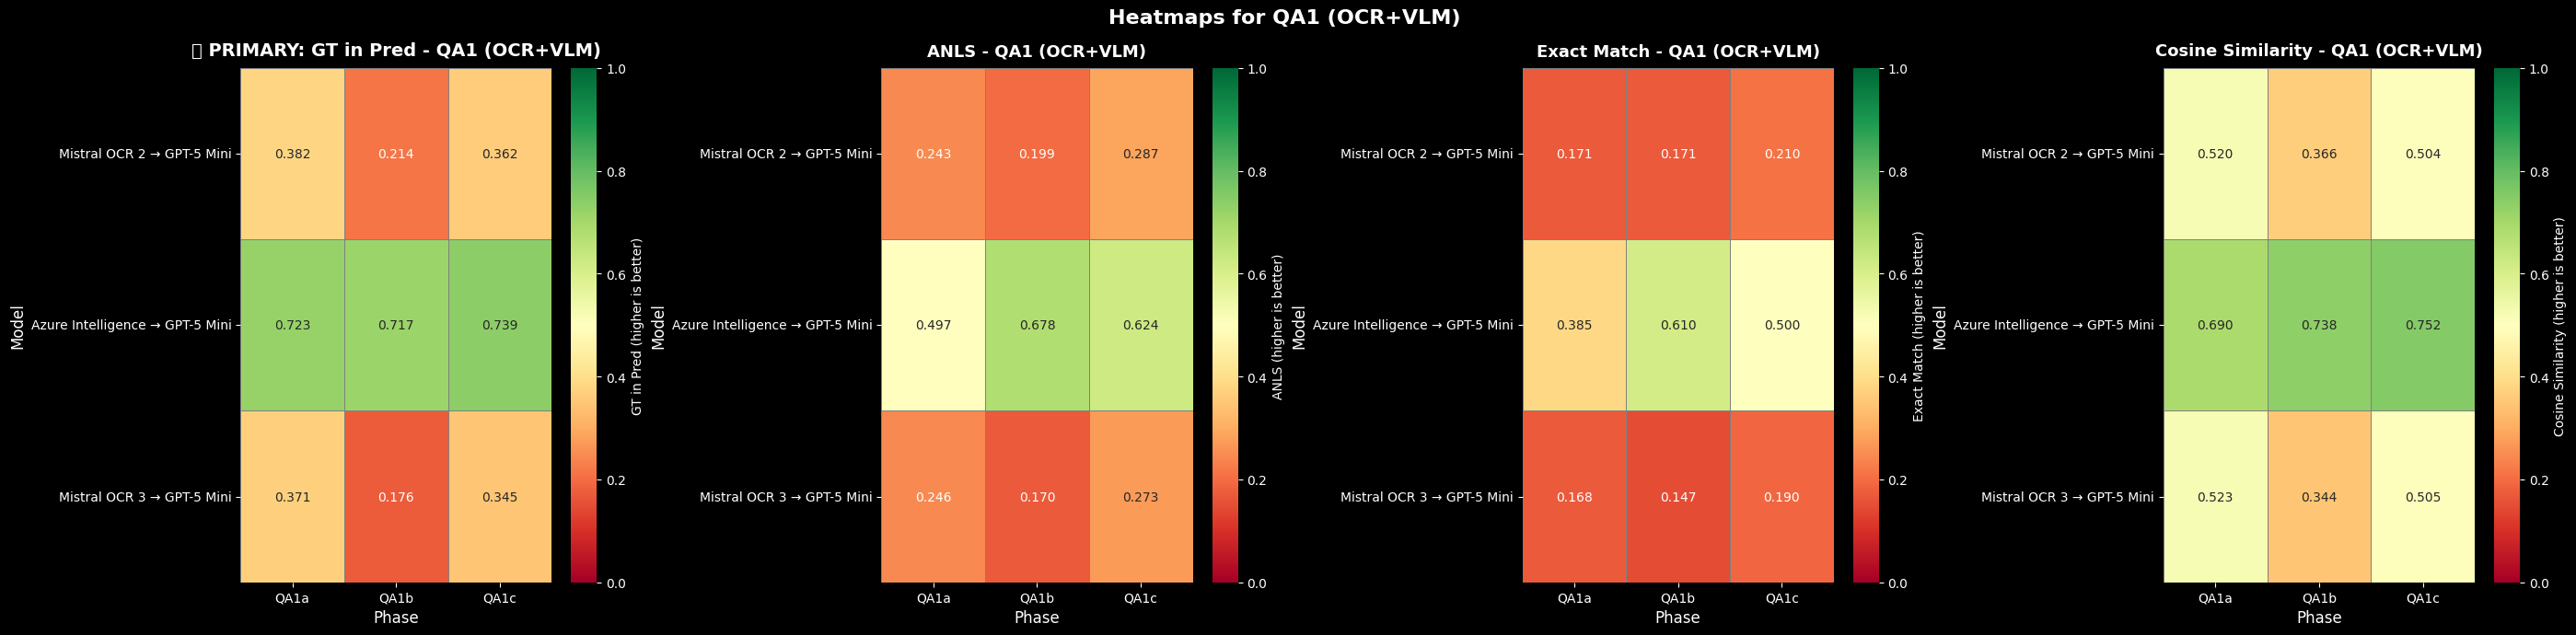

/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


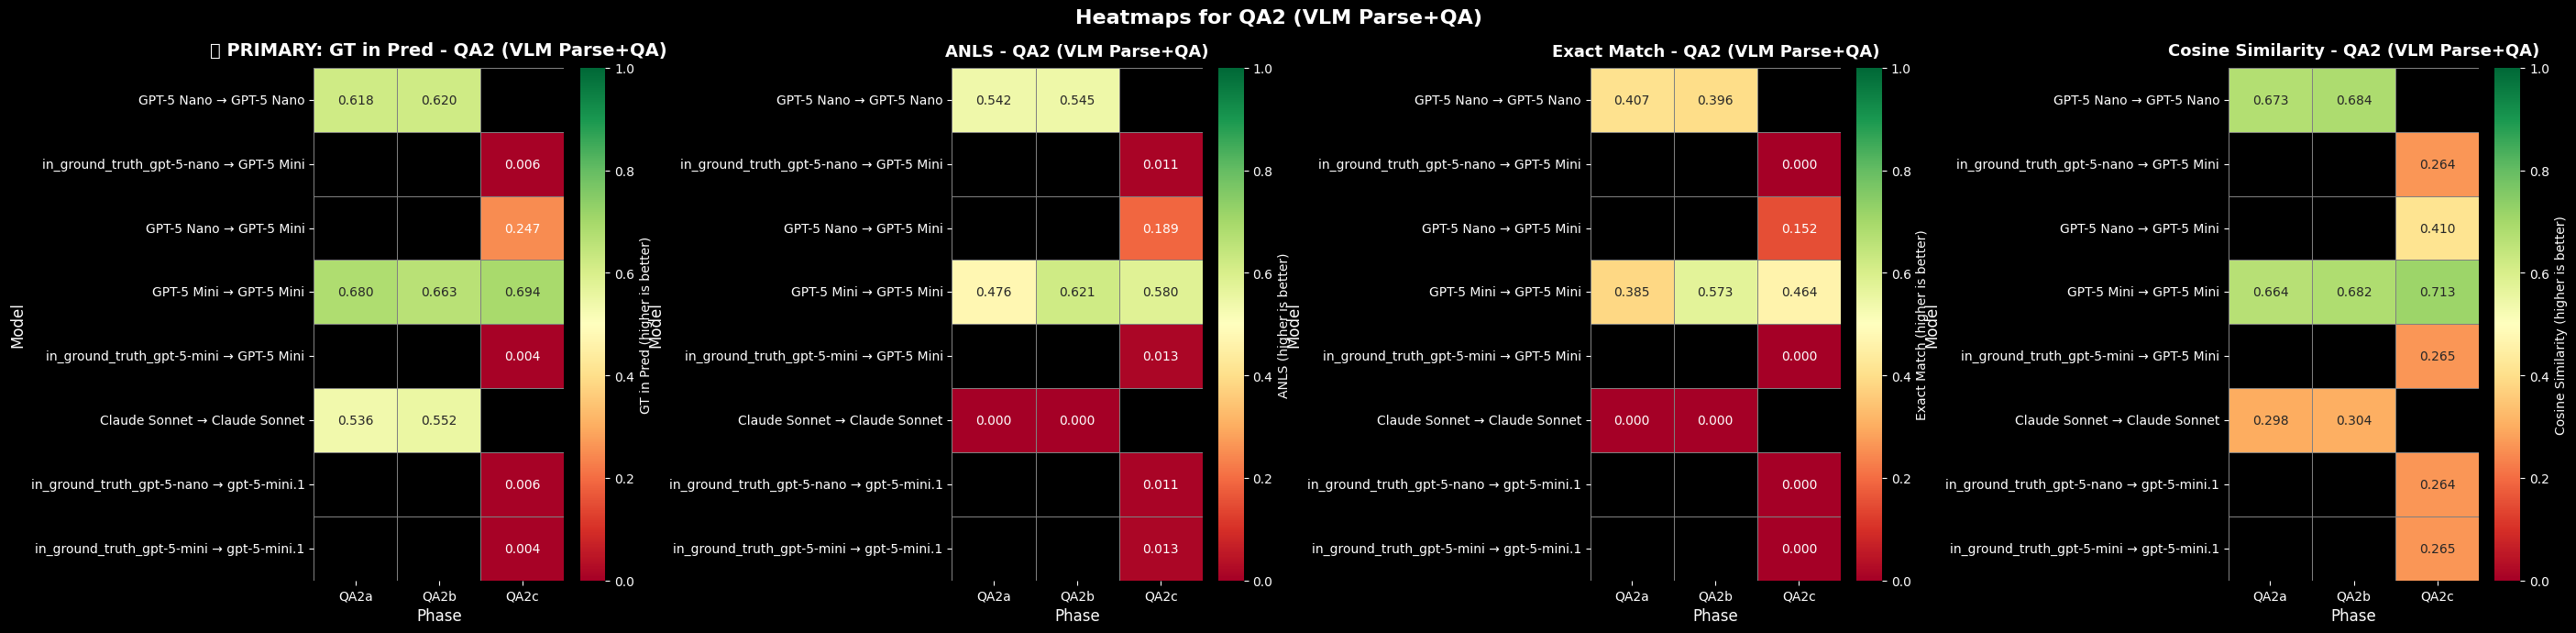

/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


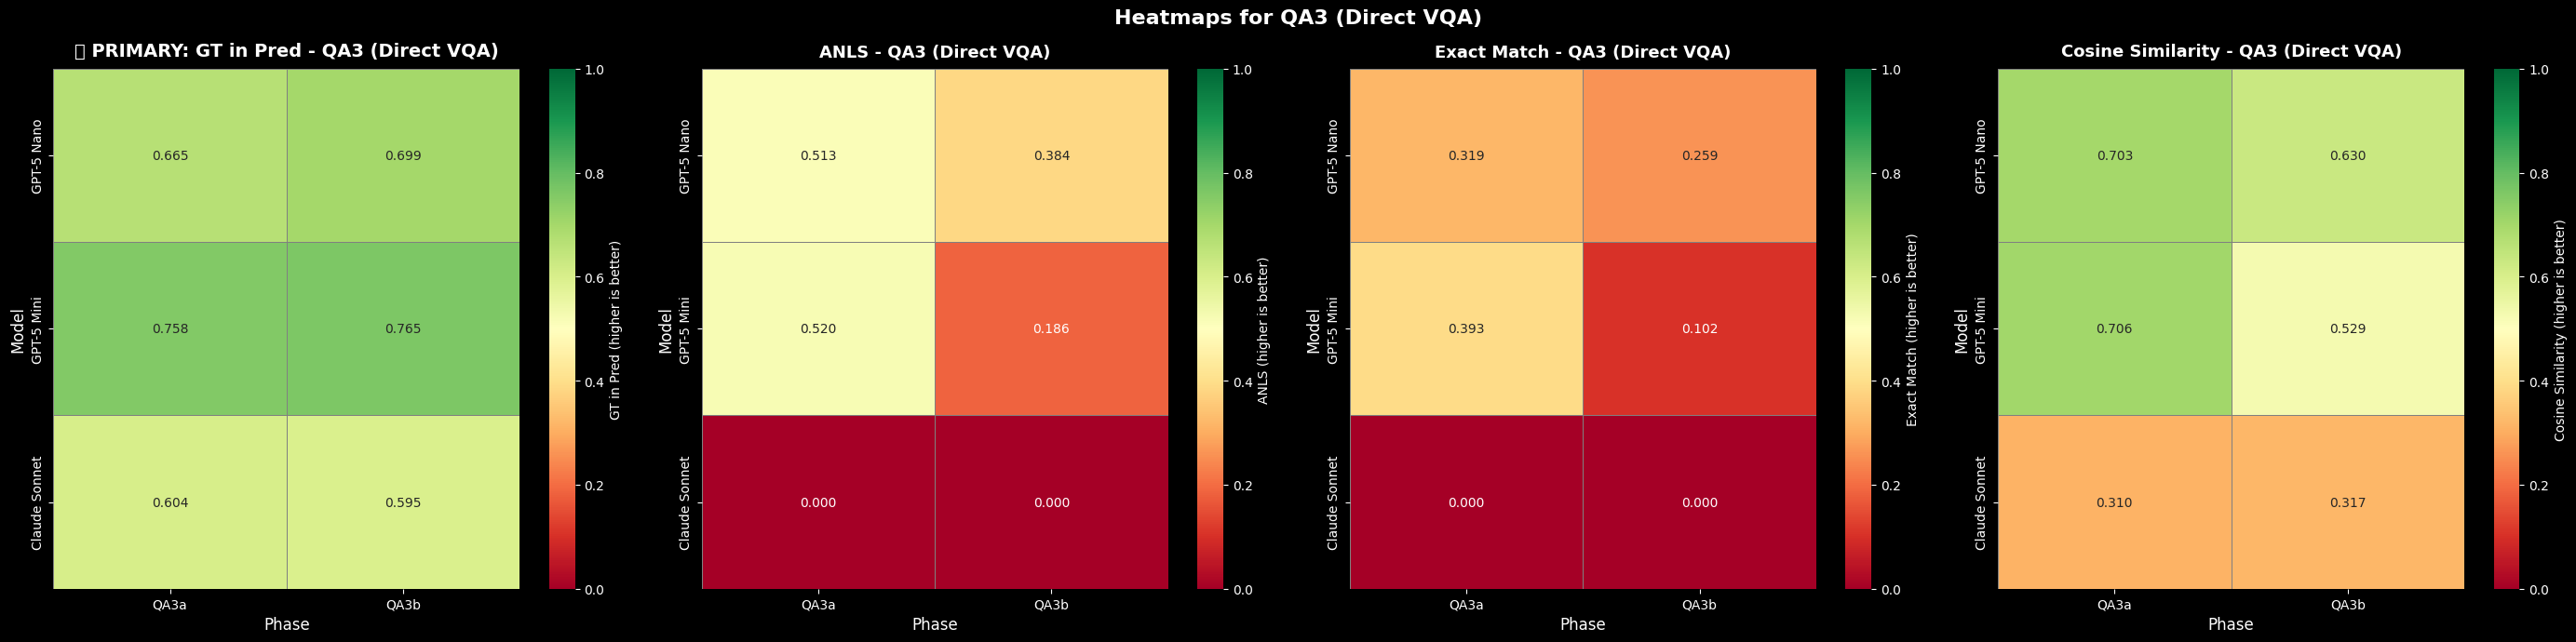


🎯 Note: 'GT in Pred' heatmaps show PRIMARY metric performance for each strategy


In [13]:
# Create separate heatmaps for QA1, QA2, and QA3 strategies
strategies_to_plot = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

metrics_to_show = ['GT in Pred', 'ANLS', 'Exact Match', 'Cosine Similarity']

for strategy_name, phases in strategies_to_plot.items():
    fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(7 * len(metrics_to_show), 7))
    
    if len(metrics_to_show) == 1:
        axes = [axes]
    
    for idx, metric_name in enumerate(metrics_to_show):
        ax = axes[idx]
        
        # Filter data for this strategy's phases
        strategy_data = {phase: metrics_results[phase] for phase in phases if phase in metrics_results}
        
        # Create heatmap data: rows = models, columns = phases
        heatmap_data = []
        model_names = []
        
        # Get all unique models across the filtered phases and sort them
        all_models = set()
        for phase_models in strategy_data.values():
            all_models.update(phase_models.keys())
        all_models = sort_models(list(all_models))
        
        # Build heatmap data
        for model in all_models:
            row_data = []
            for phase in phases:
                if phase in strategy_data and model in strategy_data[phase]:
                    # Map metric name to key
                    metric_key = metric_name.lower().replace(' ', '_')
                    value = strategy_data[phase][model].get(metric_key, np.nan)
                    row_data.append(value)
                else:
                    row_data.append(np.nan)
            
            heatmap_data.append(row_data)
            model_names.append(model)
        
        heatmap_df = pd.DataFrame(
            heatmap_data,
            index=[get_model_display_name(m) for m in model_names],
            columns=phases
        )
        
        # Use colormap: green for good, red for bad (all QA metrics: higher is better)
        cmap = 'RdYlGn'
        cbar_label = f'{metric_name} (higher is better)'
        
        sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                    ax=ax, cbar_kws={'label': cbar_label}, 
                    vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
        
        # Emphasize primary metric in title
        title_prefix = "🎯 PRIMARY: " if metric_name == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric_name} - {strategy_name}', 
                    fontsize=14 if metric_name == 'GT in Pred' else 13, 
                    fontweight='bold', pad=10)
        ax.set_xlabel('Phase', fontsize=12)
        ax.set_ylabel('Model', fontsize=12)
    
    plt.suptitle(f'Heatmaps for {strategy_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' heatmaps show PRIMARY metric performance for each strategy")

Available strategies: ['$QA_{\\text{OCR}}$', '$QA_{\\text{VLM-2stage}}$', '$QA_{\\text{VLM-direct}}$', '$QA_{\\text{special}}$']
🏆 Best Model Comparison Across Strategies (by GT in Pred)


,Model,GT in Pred,ANLS,Exact Match,Substring Match,Cosine Similarity
$QA_{\text{OCR}}$,azure_intelligence__gpt-5-mini,0.738806,0.623964,0.5,0.738806,0.752174
$QA_{\text{VLM-2stage}}$,gpt-5-mini__gpt-5-mini,0.694093,0.580321,0.464135,0.694093,0.712796
$QA_{\text{VLM-direct}}$,gpt-5-mini,0.76506,0.186113,0.10241,0.76506,0.529237
$QA_{\text{special}}$,gpt-5-mini,0.6,0.520451,0.405333,0.602667,0.716401


/var/folders/g9/llcmfs150lg102rht49jlz980000gq/T/ipykernel_44726/944924845.py:48: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


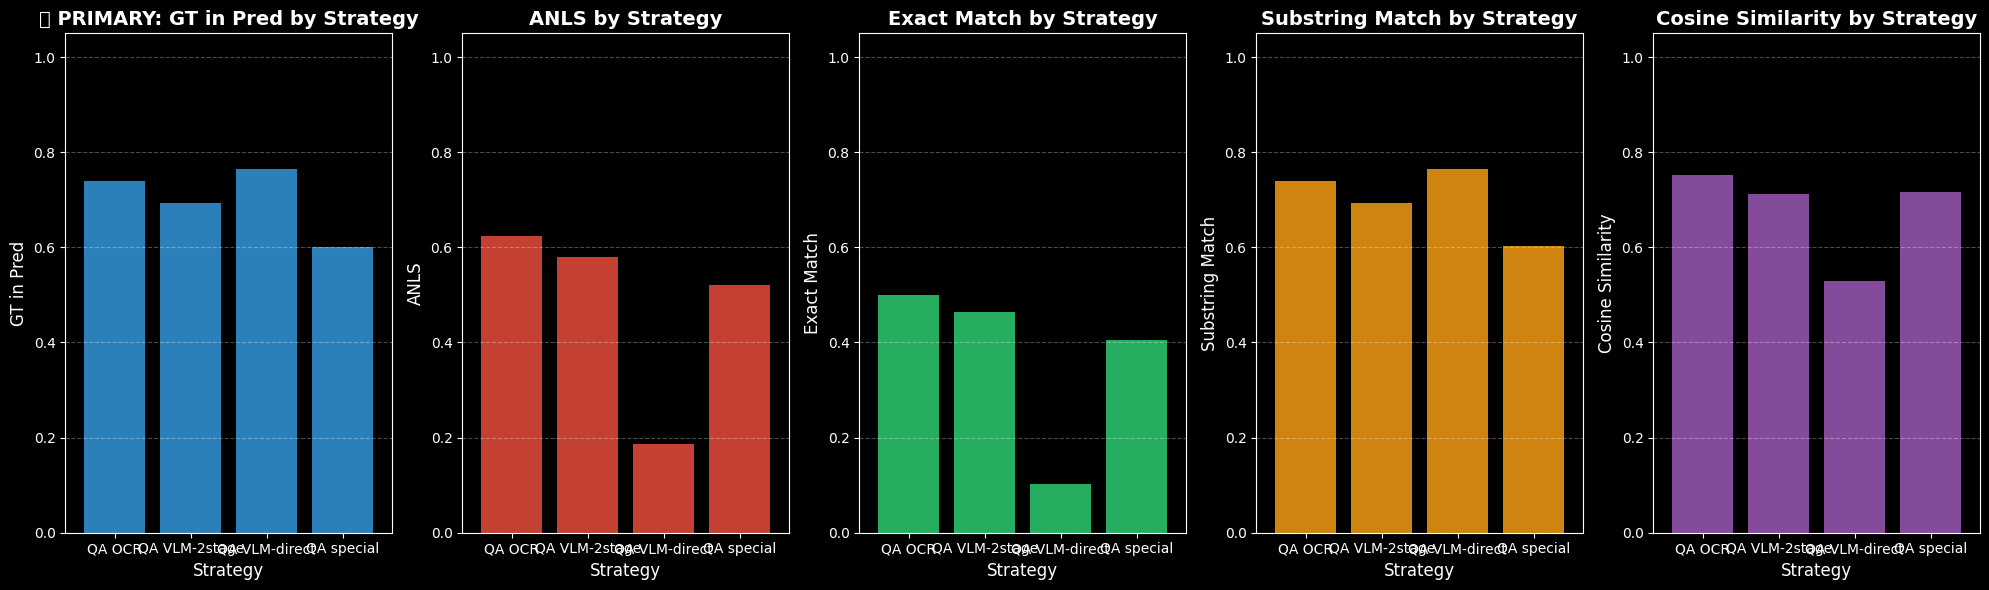

In [23]:
# Compare best models from each strategy (QA1, QA2, QA3) by GT in Pred
best_models = {}

# Use actual strategy names from summary_df (LaTeX notation)
actual_strategies = summary_df['Strategy'].unique().tolist()
print(f"Available strategies: {actual_strategies}")

for strategy in actual_strategies:
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    if len(strategy_data) == 0 or strategy_data['GT in Pred'].isna().all():
        print(f"⚠️ Skipping {strategy}: no valid data")
        continue
    best_model = strategy_data.loc[strategy_data['GT in Pred'].idxmax()]
    best_models[strategy] = best_model

if len(best_models) == 0:
    print("⚠️ No valid strategy data found")
else:
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(best_models).T
    comparison_df = comparison_df[['Model', 'GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']]

    print("🏆 Best Model Comparison Across Strategies (by GT in Pred)")
    display(comparison_df)

    # Separate bar charts for each metric
    metrics = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

    fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6))
    if len(metrics) == 1:
        axes = [axes]

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        comparison_df.set_index('Model')[metric].plot(
            kind='bar', ax=ax, color=colors[idx], alpha=0.85, width=0.8
        )
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric} by Strategy', fontsize=14, fontweight='bold')
        ax.set_xlabel('Strategy', fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        # Clean up strategy labels for x-axis display
        ax.set_xticklabels([str(s).replace('$', '').replace('_{\\text{', ' ').replace('}}', '').replace('\\text{', '').replace('}', '') for s in comparison_df.index], rotation=0)
        ax.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

## 9. Visualizations - Heatmaps

Model × Phase performance heatmaps.

/var/folders/g9/llcmfs150lg102rht49jlz980000gq/T/ipykernel_44726/3644527069.py:40: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/kenzabenkirane/Documents/GitHub/research-playground/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


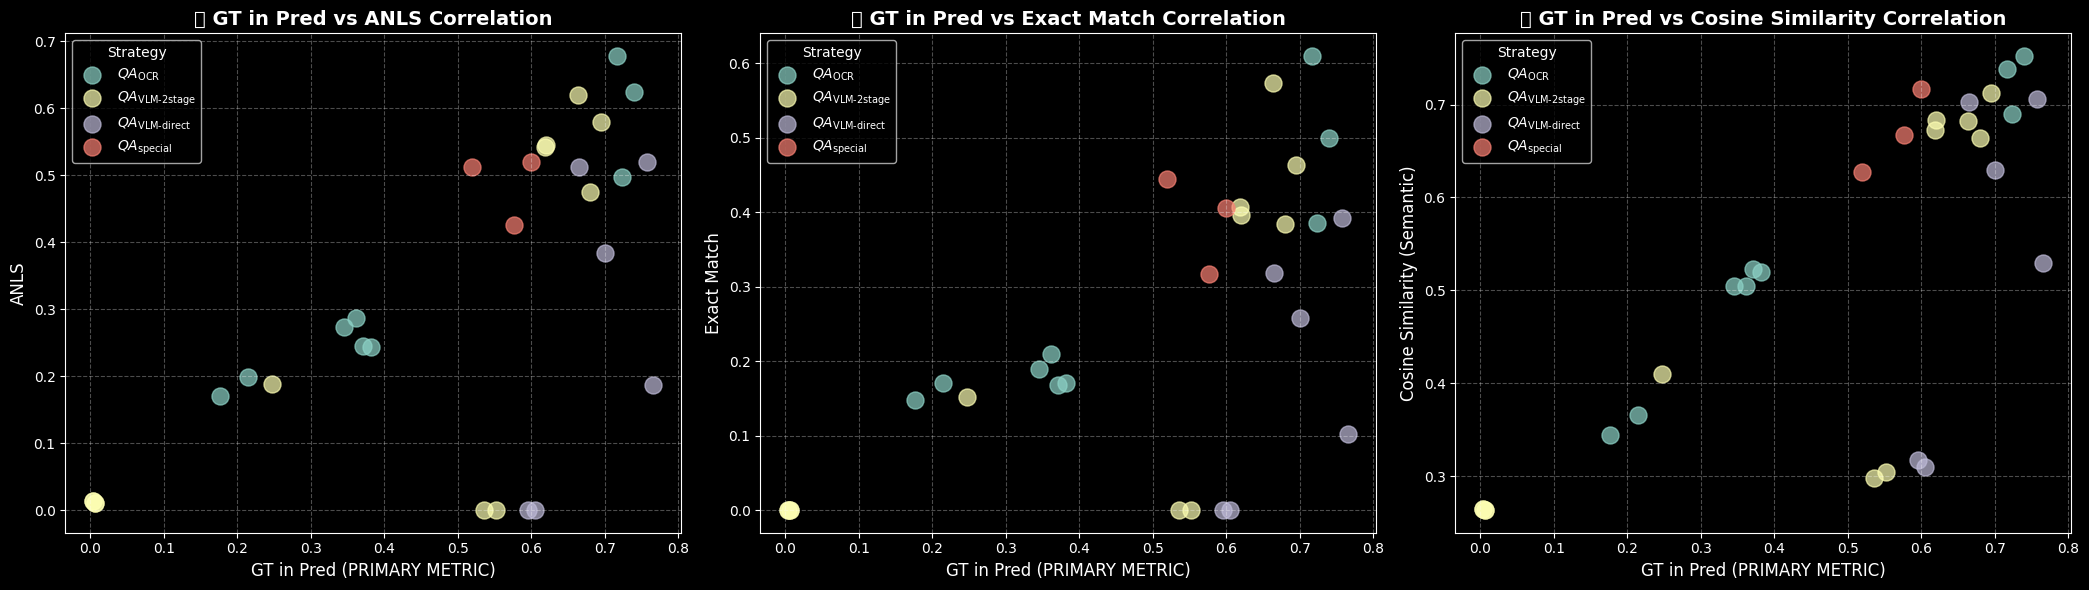


🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)


In [16]:
# Scatter plots: GT in Pred (PRIMARY) vs other metrics
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# GT in Pred vs ANLS
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['GT in Pred'], strategy_data['ANLS'],
                s=150, alpha=0.7, label=strategy)
ax1.set_title('🎯 GT in Pred vs ANLS Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax1.set_ylabel('ANLS', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Exact Match
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['GT in Pred'], strategy_data['Exact Match'],
                s=150, alpha=0.7, label=strategy)
ax2.set_title('🎯 GT in Pred vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax2.set_ylabel('Exact Match', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Cosine Similarity
ax3 = axes[2]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax3.scatter(strategy_data['GT in Pred'], strategy_data['Cosine Similarity'],
                s=150, alpha=0.7, label=strategy)
ax3.set_title('🎯 GT in Pred vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax3.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax3.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax3.legend(title='Strategy', loc='best')
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)")

## 10. Visualizations - Scatter Plots

Correlation analysis between metrics.

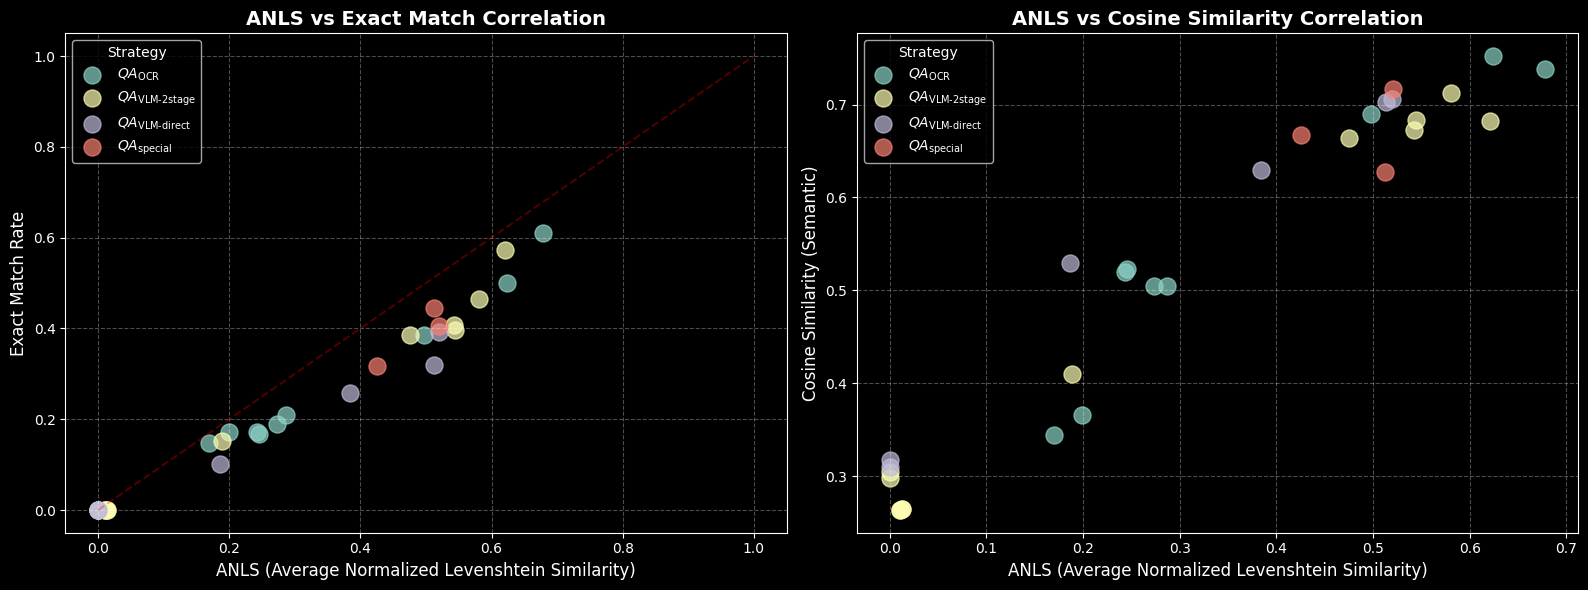

In [17]:
# Scatter plots: ANLS vs other metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANLS vs Exact Match
ax1 = axes[0]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax1.scatter(strategy_data['ANLS'], strategy_data['Exact Match'],
                s=150, alpha=0.7, label=strategy)
ax1.set_title('ANLS vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax1.set_ylabel('Exact Match Rate', fontsize=12)
ax1.legend(title='Strategy', loc='best')
ax1.grid(alpha=0.3, linestyle='--')
ax1.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='ANLS=EM')

# ANLS vs Cosine Similarity
ax2 = axes[1]
for strategy in summary_df['Strategy'].unique():
    strategy_data = summary_df[summary_df['Strategy'] == strategy]
    ax2.scatter(strategy_data['ANLS'], strategy_data['Cosine Similarity'],
                s=150, alpha=0.7, label=strategy)
ax2.set_title('ANLS vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax2.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax2.legend(title='Strategy', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [ ]:
# Heatmap of GT in Pred (PRIMARY METRIC) for each strategy group
print("\n" + "="*120)
print("🎯 PRIMARY METRIC HEATMAP: GT in Pred (Ground Truth in Prediction)")
print("="*120)
print("\nVisualization of PRIMARY metric across all phases and models\n")

# Auto-detect strategy groups from available phases
has_qa4 = any('QA4' in phase for phase in metrics_results.keys())

strategy_groups_display = {
    '$QA_{\\text{OCR}}$': ['QA1a', 'QA1b', 'QA1c'],
    '$QA_{\\text{VLM-2stage}}$': ['QA2a', 'QA2b', 'QA2c'],
    '$QA_{\\text{VLM-direct}}$': ['QA3a', 'QA3b']
}

if has_qa4:
    strategy_groups_display['$QA_{\\text{special}}$'] = ['QA4a', 'QA4b', 'QA4c']

# Create one large heatmap per strategy
for strategy_name, phases in strategy_groups_display.items():
    # Filter phases for this strategy
    strategy_phase_names = [p for p in phases if p in metrics_results]
    
    if not strategy_phase_names:
        print(f"⚠️ No phases found for {strategy_name}")
        continue
    
    # Create heatmap data: rows = models, columns = phases
    heatmap_data = []
    model_names = []
    
    # Get all unique models across the phases in this strategy
    all_models = set()
    for phase in strategy_phase_names:
        if phase in metrics_results:
            all_models.update(metrics_results[phase].keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in strategy_phase_names:
            if phase in metrics_results and model in metrics_results[phase]:
                value = metrics_results[phase][model].get('gt_in_pred', np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=[get_phase_formal_name(p) for p in strategy_phase_names]
    )
    
    # Print the table
    print(f"\n{'='*80}")
    print(f"🎯 GT in Pred (PRIMARY METRIC) - {strategy_name}")
    print(f"{'='*80}")
    display(heatmap_df)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(12, max(6, len(model_names) * 0.6)))
    
    # Use colormap: green for good (higher GT in Pred is better)
    cmap = 'RdYlGn'
    cbar_label = 'GT in Pred (PRIMARY - higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray',
                annot_kws={'fontsize': 10, 'weight': 'bold'})
    
    ax.set_title(f'🎯 GT in Pred (PRIMARY METRIC) - {strategy_name}', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Phase', fontsize=13)
    ax.set_ylabel('Model', fontsize=13)
    ax.tick_params(axis='both', labelsize=11)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*120)
print("✅ PRIMARY METRIC HEATMAPS COMPLETE")
print("="*120)
print("\n💡 Interpretation Guide:")
print("  • Green cells = High GT in Pred (prediction contains ground truth)")
print("  • Red cells = Low GT in Pred (ground truth missing from prediction)")
print("  • This is the PRIMARY metric for evaluating QA performance")
print("  • Compare across phases to see which strategy works best for each model")

## 11. QA-Specific Analysis

Analyze question types, answer lengths, and QA-specific patterns.

## 10.5 Ground Truth in Parsed Data Analysis

Heatmap visualization for "Ground Truth in Parsed Data" metric across all experiments.



GROUND TRUTH IN PARSED DATA - Comprehensive Analysis

This metric measures whether ground truth answers appear in parsed/extracted text.
High values indicate strong parsing effectiveness. We analyze this vs QA performance metrics.


--- Part 1: Heatmap Visualizations ---


Ground Truth in Parsed Data - QA1 (OCR+VLM)

Ground Truth in Parsed Data - QA1 (OCR+VLM):


,QA1a,QA1b,QA1c
Mistral OCR 2 → GPT-5 Mini,0.357456,0.346232,0.338330
Azure Intelligence → GPT-5 Mini,0.746479,0.739229,0.753731
Mistral OCR 3 → GPT-5 Mini,0.321121,0.325253,0.318777


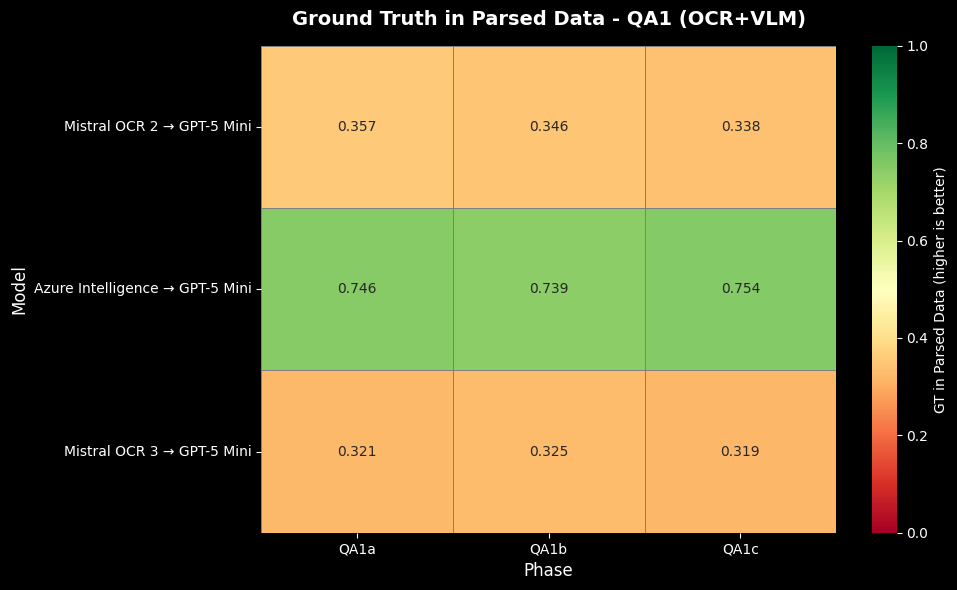


Ground Truth in Parsed Data - QA2 (VLM Parse+QA)

Ground Truth in Parsed Data - QA2 (VLM Parse+QA):


,QA2a,QA2b,QA2c
GPT-5 Nano → GPT-5 Nano,0.625000,0.649203,NaN
in_ground_truth_gpt-5-nano → GPT-5 Mini,NaN,NaN,0.000000
GPT-5 Nano → GPT-5 Mini,NaN,NaN,0.116424
GPT-5 Mini → GPT-5 Mini,0.694387,0.685714,0.700422
in_ground_truth_gpt-5-mini → GPT-5 Mini,NaN,NaN,0.000000
Claude Sonnet → Claude Sonnet,0.644550,0.646919,NaN
in_ground_truth_gpt-5-nano → gpt-5-mini.1,NaN,NaN,0.000000
in_ground_truth_gpt-5-mini → gpt-5-mini.1,NaN,NaN,0.000000


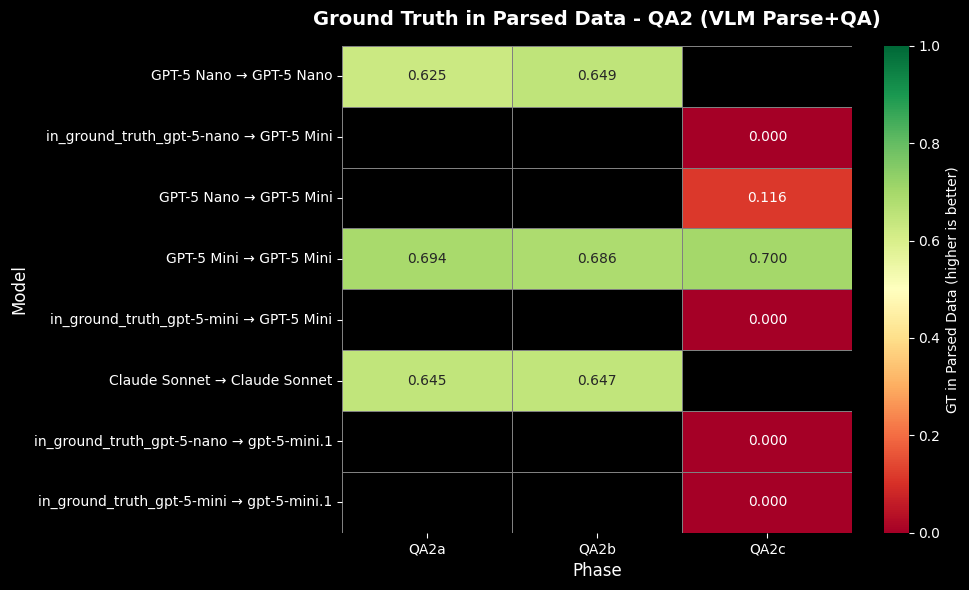


Ground Truth in Parsed Data - QA3 (Direct VQA)

Ground Truth in Parsed Data - QA3 (Direct VQA):


,QA3a,QA3b
GPT-5 Nano,0.0,0.0
GPT-5 Mini,0.0,0.0
Claude Sonnet,0.0,0.0


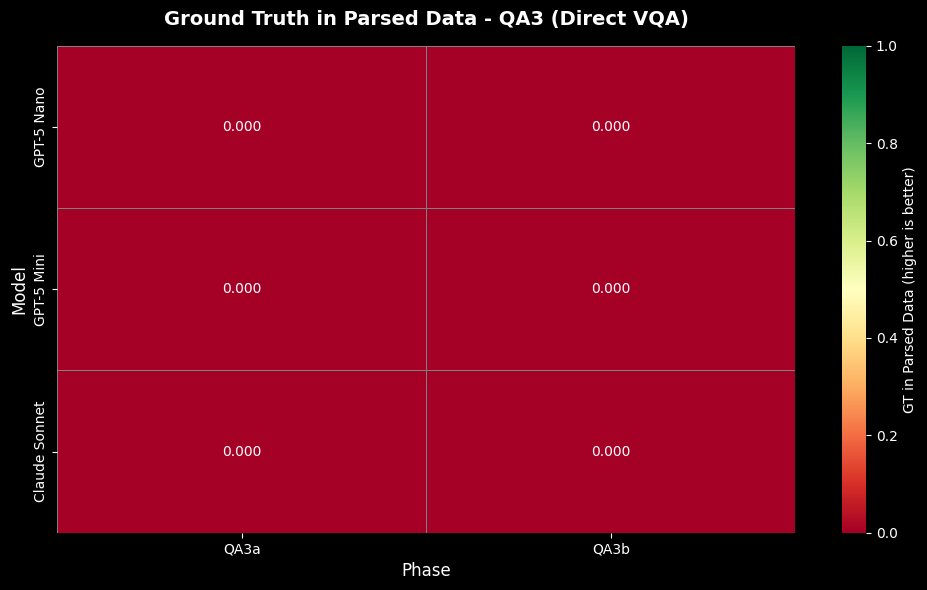


Ground Truth in Parsed Data - QA4 (Special)

Ground Truth in Parsed Data - QA4 (Special):


,QA4a,QA4b,QA4c
GPT-5 Mini,0.65099,0.638889,0.634667


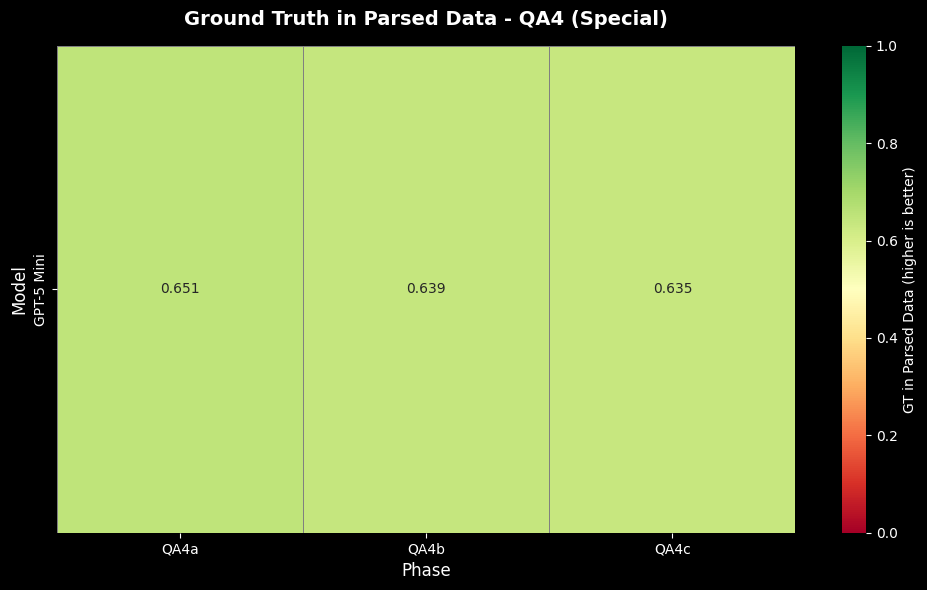



--- Part 2: Regression Analysis ---

QA1 (OCR+VLM):
  Regression: y = 1.0130x + -0.0305
  R² = 0.8973, Pearson r = 0.9472, p-value = 0.000105
QA2 (VLM Parse+QA):
  Regression: y = 0.9034x + 0.0273
  R² = 0.9734, Pearson r = 0.9866, p-value = 0.000000
QA3 (Direct VQA): Insufficient variance for regression fit
QA4 (Special):
  Regression: y = -0.0450x + 0.5939
  R² = 0.0001, Pearson r = -0.0091, p-value = 0.994219
QA1 (OCR+VLM):
  ANLS Regression: y = 0.8777x + -0.0567
  R² = 0.9002, Pearson r = 0.9488, p-value = 0.000095
QA2 (VLM Parse+QA):
  ANLS Regression: y = 0.5660x + 0.0254
  R² = 0.4706, Pearson r = 0.6860, p-value = 0.013766
QA3 (Direct VQA): Insufficient variance for ANLS regression
QA4 (Special):
  ANLS Regression: y = -6.1206x + 4.4123
  R² = 0.9715, Pearson r = -0.9857, p-value = 0.107901


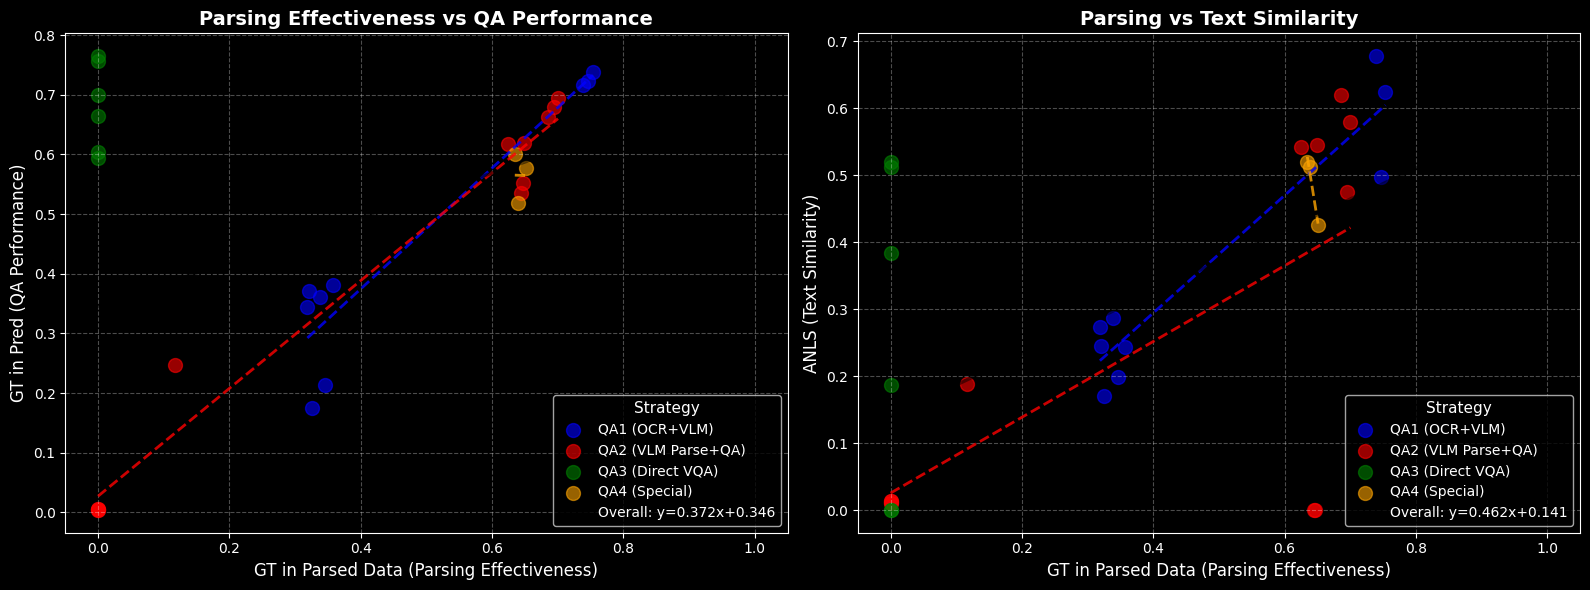


INTERPRETATION GUIDE

• High R² values (>0.5) indicate strong linear relationship between parsing and QA performance
• Positive slopes suggest: better parsing → better QA results
• Steep slopes mean parsing improvements significantly boost QA performance
• Low p-values (<0.05) indicate statistically significant relationships
• Comparison helps identify: Is parsing or LLM QA the bottleneck?



In [18]:
from scipy import stats

print("\n" + "="*120)
print("GROUND TRUTH IN PARSED DATA - Comprehensive Analysis")
print("="*120)
print("\nThis metric measures whether ground truth answers appear in parsed/extracted text.")
print("High values indicate strong parsing effectiveness. We analyze this vs QA performance metrics.\n")

# Auto-detect strategy groups from available phases
has_qa4 = any('QA4' in phase for phase in metrics_results.keys())

strategy_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b']
}

if has_qa4:
    strategy_groups['QA4 (Special)'] = ['QA4a', 'QA4b', 'QA4c']

# Color mapping for strategies
strategy_colors = {
    'QA1 (OCR+VLM)': 'blue',
    'QA2 (VLM Parse+QA)': 'red',
    'QA3 (Direct VQA)': 'green',
    'QA4 (Special)': 'orange'
}

# ============================================================================
# Part 1: Heatmap Visualizations
# ============================================================================
print("\n--- Part 1: Heatmap Visualizations ---\n")

for strategy_name, phases in strategy_groups.items():
    print(f"\n{'='*80}")
    print(f"Ground Truth in Parsed Data - {strategy_name}")
    print(f"{'='*80}")
    
    # Filter phases for this strategy
    strategy_phase_names = [p for p in phases if p in metrics_results]
    if not strategy_phase_names:
        print(f"⚠️ No phases found for {strategy_name}")
        continue
    
    # Create heatmap data: rows = models, columns = phases in this strategy
    heatmap_data = []
    model_names = []
    
    # Get all unique models across the phases in this strategy
    all_models = set()
    for phase in strategy_phase_names:
        if phase in metrics_results:
            all_models.update(metrics_results[phase].keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in strategy_phase_names:
            if phase in metrics_results and model in metrics_results[phase]:
                value = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=strategy_phase_names
    )
    
    # Print the table
    print(f"\nGround Truth in Parsed Data - {strategy_name}:")
    display(heatmap_df)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Use colormap: green for good, red for bad
    cmap = 'RdYlGn'
    cbar_label = 'GT in Parsed Data (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    ax.set_title(f'Ground Truth in Parsed Data - {strategy_name}', 
                fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# Part 2: Regression Analysis - GT in Parsed Data vs GT in Pred
# ============================================================================
print("\n\n--- Part 2: Regression Analysis ---\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot 1: GT in Parsed Data vs GT in Pred
ax1 = axes[0]
x_vals_all = []
y_vals_all = []

for strategy_name in strategy_groups.keys():
    x_vals = []
    y_vals = []
    
    for phase in strategy_groups[strategy_name]:
        if phase in metrics_results:
            for model in metrics_results[phase]:
                gt_parsed = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                gt_pred = metrics_results[phase][model].get('gt_in_pred', np.nan)
                
                if not np.isnan(gt_parsed) and not np.isnan(gt_pred):
                    x_vals.append(gt_parsed)
                    y_vals.append(gt_pred)
    
    if x_vals:
        x_vals_all.extend(x_vals)
        y_vals_all.extend(y_vals)
        
        # Plot points
        ax1.scatter(x_vals, y_vals, s=100, alpha=0.6, 
                   label=strategy_name, color=strategy_colors.get(strategy_name, 'gray'))
        
        # Linear regression for this strategy (with error handling)
        try:
            if len(set(x_vals)) > 1 and len(set(y_vals)) > 1:  # Check for variance
                z = np.polyfit(x_vals, y_vals, 1)
                p = np.poly1d(z)
                x_line = np.linspace(min(x_vals), max(x_vals), 100)
                y_line = p(x_line)
                ax1.plot(x_line, y_line, color=strategy_colors.get(strategy_name, 'gray'), 
                        linestyle='--', linewidth=2, alpha=0.8)
                
                # Calculate statistics
                slope, intercept = z[0], z[1]
                r_value, p_value = stats.pearsonr(x_vals, y_vals)
                r_squared = r_value ** 2
                
                print(f"{strategy_name}:")
                print(f"  Regression: y = {slope:.4f}x + {intercept:.4f}")
                print(f"  R² = {r_squared:.4f}, Pearson r = {r_value:.4f}, p-value = {p_value:.6f}")
            else:
                print(f"{strategy_name}: Insufficient variance for regression fit")
        except Exception as e:
            print(f"{strategy_name}: Could not fit regression - {str(e)}")

ax1.set_xlabel('GT in Parsed Data (Parsing Effectiveness)', fontsize=12)
ax1.set_ylabel('GT in Pred (QA Performance)', fontsize=12)
ax1.set_title('Parsing Effectiveness vs QA Performance', fontsize=14, fontweight='bold')
ax1.legend(title='Strategy', fontsize=10, title_fontsize=11)
ax1.grid(alpha=0.3, linestyle='--')

# Overall linear fit
if x_vals_all and y_vals_all:
    try:
        if len(set(x_vals_all)) > 1 and len(set(y_vals_all)) > 1:  # Check for variance
            z_all = np.polyfit(x_vals_all, y_vals_all, 1)
            p_all = np.poly1d(z_all)
            x_line_all = np.linspace(0, 1, 100)
            y_line_all = p_all(x_line_all)
            ax1.plot(x_line_all, y_line_all, 'k-', linewidth=2.5, alpha=0.5, label=f'Overall: y={z_all[0]:.3f}x+{z_all[1]:.3f}')
            ax1.legend(title='Strategy', fontsize=10, title_fontsize=11)
        else:
            print("Overall: Insufficient variance for overall regression fit")
    except Exception as e:
        print(f"Overall: Could not fit overall regression - {str(e)}")

# Scatter plot 2: GT in Parsed Data vs ANLS
ax2 = axes[1]
x_vals_all = []
y_vals_all = []

for strategy_name in strategy_groups.keys():
    x_vals = []
    y_vals = []
    
    for phase in strategy_groups[strategy_name]:
        if phase in metrics_results:
            for model in metrics_results[phase]:
                gt_parsed = metrics_results[phase][model].get('gt_in_parsed', np.nan)
                anls = metrics_results[phase][model].get('anls', np.nan)
                
                if not np.isnan(gt_parsed) and not np.isnan(anls):
                    x_vals.append(gt_parsed)
                    y_vals.append(anls)
    
    if x_vals:
        x_vals_all.extend(x_vals)
        y_vals_all.extend(y_vals)
        
        # Plot points
        ax2.scatter(x_vals, y_vals, s=100, alpha=0.6, 
                   label=strategy_name, color=strategy_colors.get(strategy_name, 'gray'))
        
        # Linear regression for this strategy (with error handling)
        try:
            if len(set(x_vals)) > 1 and len(set(y_vals)) > 1:  # Check for variance
                z = np.polyfit(x_vals, y_vals, 1)
                p = np.poly1d(z)
                x_line = np.linspace(min(x_vals), max(x_vals), 100)
                y_line = p(x_line)
                ax2.plot(x_line, y_line, color=strategy_colors.get(strategy_name, 'gray'), 
                        linestyle='--', linewidth=2, alpha=0.8)
                
                # Calculate statistics
                slope, intercept = z[0], z[1]
                r_value, p_value = stats.pearsonr(x_vals, y_vals)
                r_squared = r_value ** 2
                
                print(f"{strategy_name}:")
                print(f"  ANLS Regression: y = {slope:.4f}x + {intercept:.4f}")
                print(f"  R² = {r_squared:.4f}, Pearson r = {r_value:.4f}, p-value = {p_value:.6f}")
            else:
                print(f"{strategy_name}: Insufficient variance for ANLS regression")
        except Exception as e:
            print(f"{strategy_name}: Could not fit ANLS regression - {str(e)}")

ax2.set_xlabel('GT in Parsed Data (Parsing Effectiveness)', fontsize=12)
ax2.set_ylabel('ANLS (Text Similarity)', fontsize=12)
ax2.set_title('Parsing vs Text Similarity', fontsize=14, fontweight='bold')
ax2.legend(title='Strategy', fontsize=10, title_fontsize=11)
ax2.grid(alpha=0.3, linestyle='--')

# Overall linear fit
if x_vals_all and y_vals_all:
    try:
        if len(set(x_vals_all)) > 1 and len(set(y_vals_all)) > 1:  # Check for variance
            z_all = np.polyfit(x_vals_all, y_vals_all, 1)
            p_all = np.poly1d(z_all)
            x_line_all = np.linspace(0, 1, 100)
            y_line_all = p_all(x_line_all)
            ax2.plot(x_line_all, y_line_all, 'k-', linewidth=2.5, alpha=0.5, label=f'Overall: y={z_all[0]:.3f}x+{z_all[1]:.3f}')
            ax2.legend(title='Strategy', fontsize=10, title_fontsize=11)
        else:
            print("Overall: Insufficient variance for overall ANLS regression fit")
    except Exception as e:
        print(f"Overall: Could not fit overall ANLS regression - {str(e)}")

plt.tight_layout()
plt.show()

print("\n" + "="*120)
print("INTERPRETATION GUIDE")
print("="*120)
print("""
• High R² values (>0.5) indicate strong linear relationship between parsing and QA performance
• Positive slopes suggest: better parsing → better QA results
• Steep slopes mean parsing improvements significantly boost QA performance
• Low p-values (<0.05) indicate statistically significant relationships
• Comparison helps identify: Is parsing or LLM QA the bottleneck?
""")


Question Type Distribution (QA1a):
  What           :  205 questions ( 41.0%)
  Which          :  116 questions ( 23.2%)
  How many/much  :   82 questions ( 16.4%)
  Other          :   48 questions (  9.6%)
  Who            :   23 questions (  4.6%)
  When           :   16 questions (  3.2%)
  Where          :    8 questions (  1.6%)
  How            :    2 questions (  0.4%)


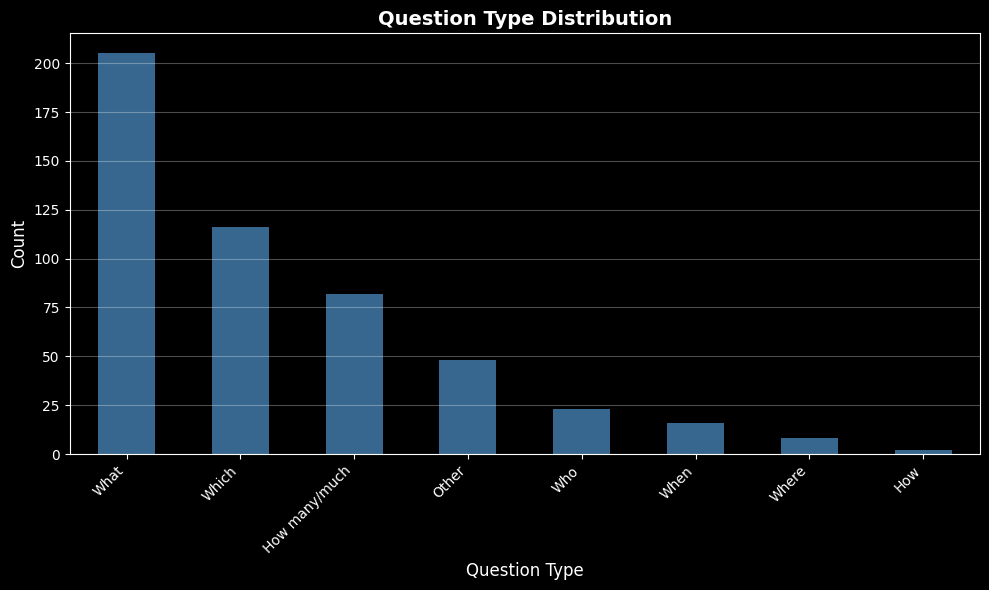

In [19]:
# Question type analysis
if len(phase_dfs) > 0:
    # Use first available phase for analysis
    analysis_phase = list(phase_dfs.keys())[0]
    df_analysis = phase_dfs[analysis_phase].copy()
    
    # Add question type categorization
    df_analysis['question_type'] = df_analysis['question'].apply(categorize_question_type)
    
    print(f"\nQuestion Type Distribution ({analysis_phase}):")
    print("=" * 80)
    type_counts = df_analysis['question_type'].value_counts()
    for qtype, count in type_counts.items():
        pct = count / len(df_analysis) * 100
        print(f"  {qtype:15s}: {count:4d} questions ({pct:5.1f}%)")
    
    # Visualize question types
    fig, ax = plt.subplots(figsize=(10, 6))
    type_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title('Question Type Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

/var/folders/g9/llcmfs150lg102rht49jlz980000gq/T/ipykernel_44726/3520156420.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')


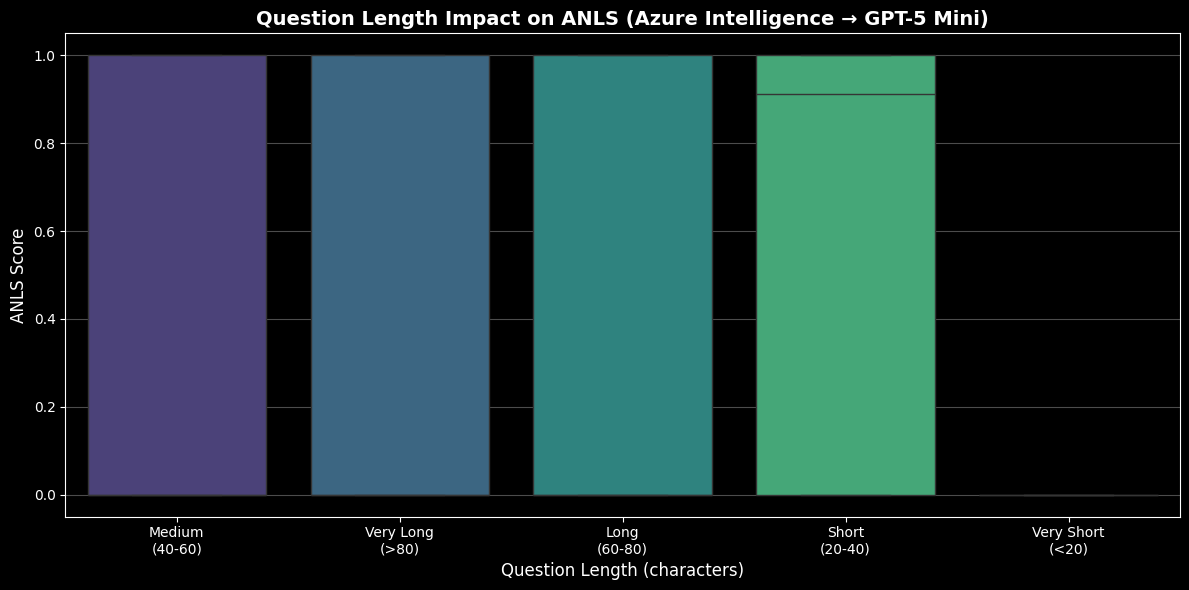

In [20]:
# Question length impact on performance
if len(phase_dfs) > 0:
    df_analysis['question_length'] = df_analysis['question'].astype(str).str.len()
    df_analysis['question_length_bin'] = pd.cut(
        df_analysis['question_length'],
        bins=[0, 20, 40, 60, 80, 1000],
        labels=['Very Short\n(<20)', 'Short\n(20-40)', 'Medium\n(40-60)', 'Long\n(60-80)', 'Very Long\n(>80)']
    )
    
    # Calculate ANLS for first model per length bin
    pred_col = [col for col in df_analysis.columns if col.startswith('prediction_')][0]
    model_name = pred_col.replace('prediction_', '')
    
    anls_by_length = []
    for _, row in df_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[pred_col]), ground_truths, threshold=0.5)
        anls_by_length.append({
            'question_length_bin': row['question_length_bin'],
            'anls': anls
        })
    
    anls_length_df = pd.DataFrame(anls_by_length)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')
    ax.set_title(f'Question Length Impact on ANLS ({get_model_display_name(model_name)})', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Length (characters)', fontsize=12)
    ax.set_ylabel('ANLS Score', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

TypeError: no numeric data to plot

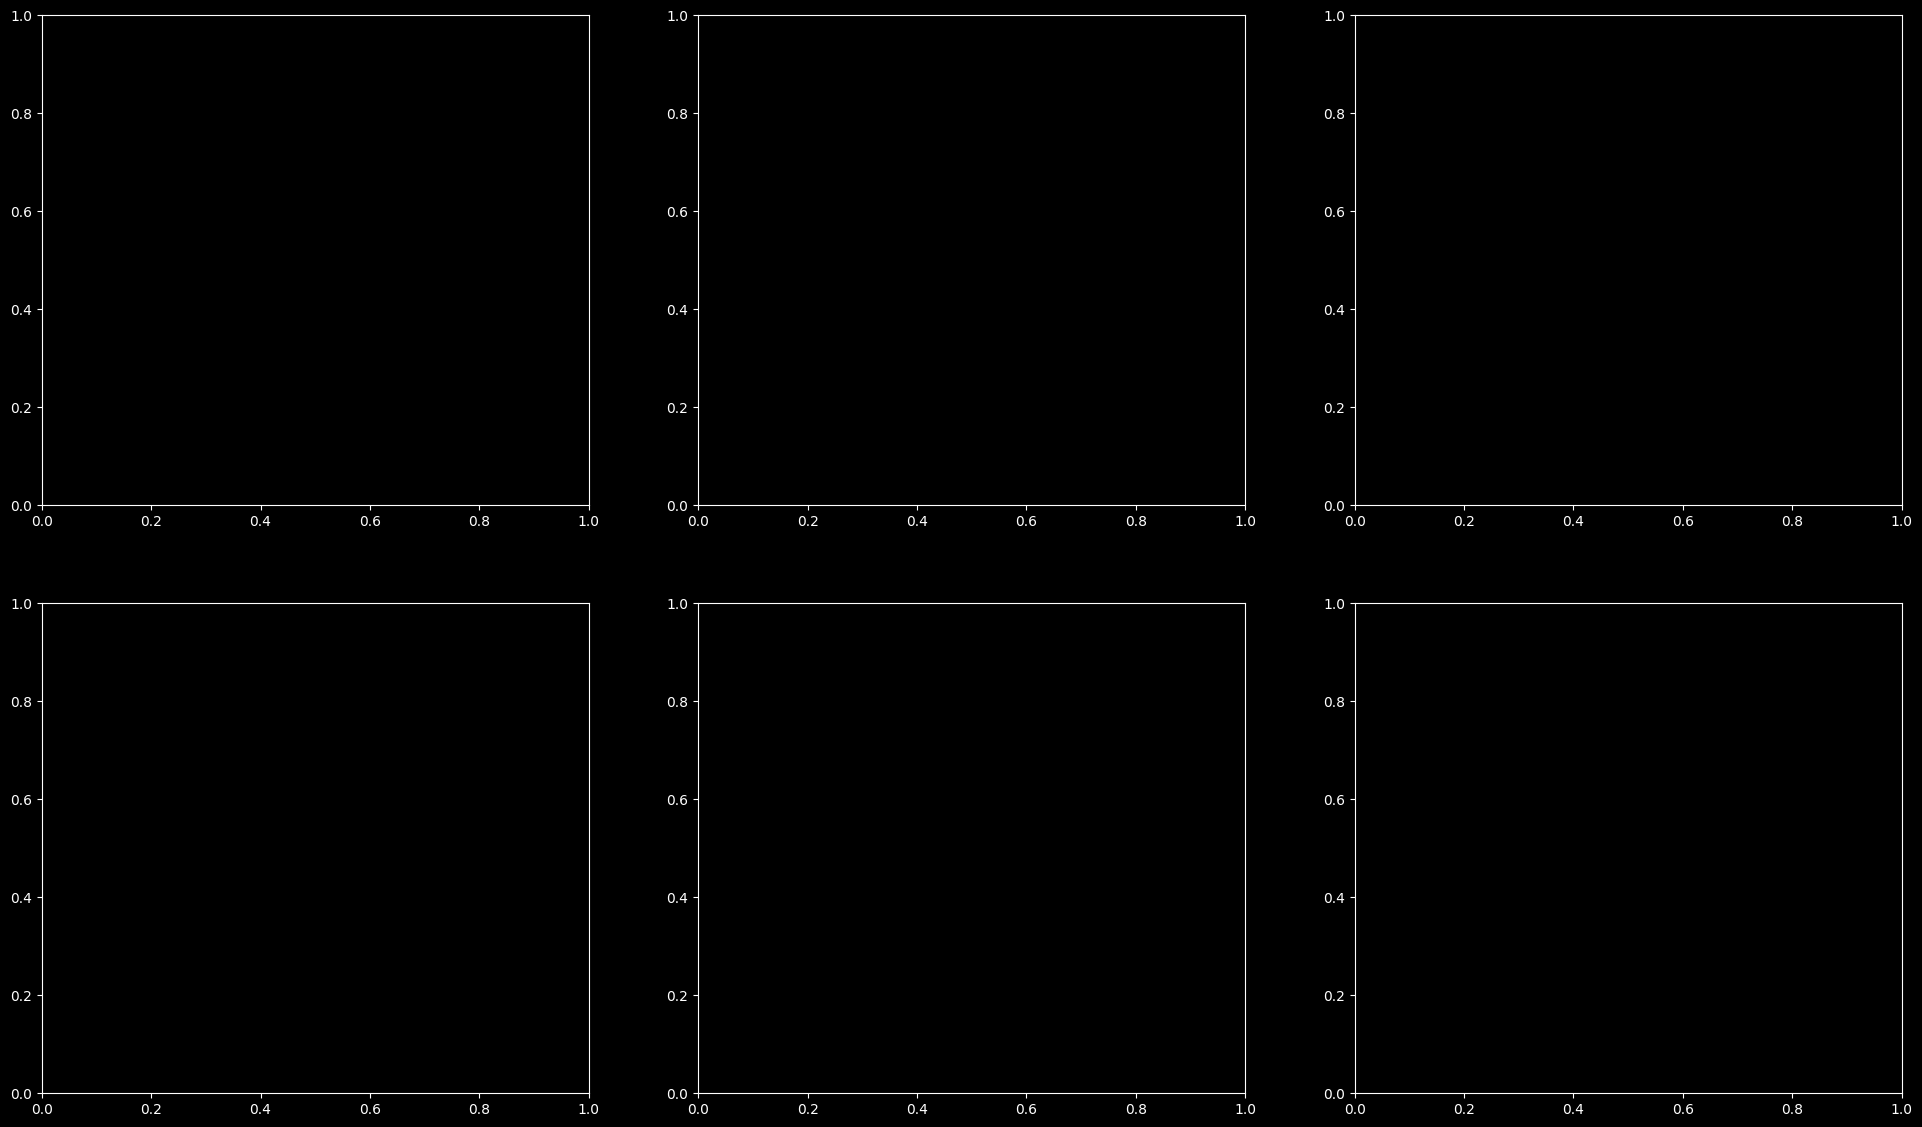

In [21]:
# Bar charts for each metric (PRIMARY METRIC FIRST) - one figure per strategy
strategies = ['QA1 (OCR+VLM)', 'QA2 (VLM Parse+QA)', 'QA3 (Direct VQA)']
metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6', '#34495e', '#16a085', '#c0392b']

for strategy in strategies:
    # Filter data for this strategy
    strategy_df = summary_df[summary_df['Strategy'] == strategy]
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Group by Model and Strategy, then take mean to handle duplicates
        grouped_df = strategy_df.groupby(['Model', 'Strategy'])[metric].mean().reset_index()
        
        # Pivot data for grouped bar chart
        pivot_data = grouped_df.pivot(index='Model', columns='Strategy', values=metric)
        
        # Sort models
        pivot_data = pivot_data.reindex(sort_models(pivot_data.index.tolist()))
        
        pivot_data.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_data.columns)], alpha=0.85, width=0.8)
        
        # Emphasize primary metric
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        title_suffix = " [PRIMARY METRIC]" if metric == 'GT in Pred' else ""
        
        ax.set_title(f'{title_prefix}{metric} by Model ({strategy}){title_suffix}', 
                     fontsize=15 if metric == 'GT in Pred' else 14, 
                     fontweight='bold', pad=15)
        ax.set_xlabel('Model', fontsize=13)
        ax.set_ylabel(metric, fontsize=13)
        ax.legend(title='Strategy', title_fontsize=12, fontsize=10, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xticklabels([get_model_display_name(m) for m in pivot_data.index], rotation=45, ha='right')
        ax.set_ylim(0, 1.05)
        
        # Add value labels on bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
    
    # Hide last subplot if not needed
    if len(metrics_to_plot) < 6:
        axes[-1].set_visible(False)
    
    plt.suptitle(f'Bar Charts for {strategy}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")


## 12. Phase Comparison Analysis

Compare the four QA strategies: OCR+VLM, VLM Parse+QA, Direct VQA, and QA4 Special Strategy.


Strategy Comparison:

QA1 (OCR+VLM):
  Mean GT in Pred: 0.4574 [PRIMARY]
  Mean ANLS: 0.3608
  Mean Exact Match: 0.2907
  Mean Substring Match: 0.4605
  Phases included: QA1a, QA1b, QA1c

QA2 (VLM Parse+QA):
  Mean GT in Pred: 0.3962 [PRIMARY]
  Mean ANLS: 0.2519
  Mean Exact Match: 0.2032
  Mean Substring Match: 0.3971
  Phases included: QA2a, QA2b, QA2c

QA3 (Direct VQA):
  Mean GT in Pred: 0.6994 [PRIMARY]
  Mean ANLS: 0.2686
  Mean Exact Match: 0.1824
  Mean Substring Match: 0.7007
  Phases included: QA3a, QA3b

QA4 (Special Strategy):
  Mean GT in Pred: 0.5808 [PRIMARY]
  Mean ANLS: 0.4912
  Mean Exact Match: 0.4014
  Mean Substring Match: 0.5872
  Phases included: QA4a, QA4b, QA4c


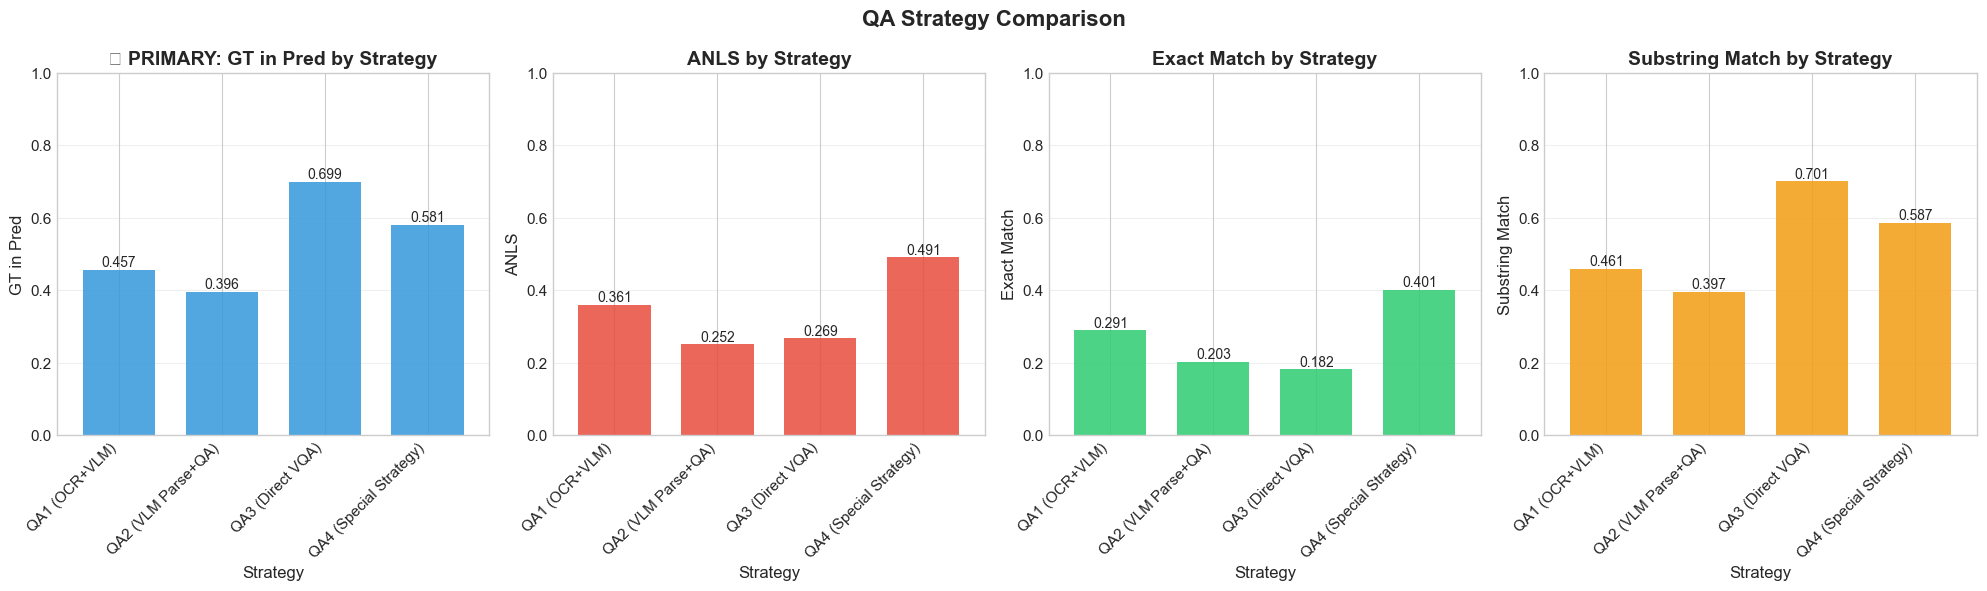

In [ ]:
from matplotlib.container import BarContainer

# Group phases by strategy (INCLUDING QA4)
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b'],
    'QA4 (Special Strategy)': ['QA4a', 'QA4b', 'QA4c']
}

print("\nStrategy Comparison:")
print("=" * 100)

strategy_results = []
for group_name, phases in phase_groups.items():
    group_data = summary_df[summary_df['Phase'].isin(phases)]
    if len(group_data) > 0:
        avg_gt_in_pred = group_data['GT in Pred'].mean()  # PRIMARY METRIC
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  Mean GT in Pred: {avg_gt_in_pred:.4f} [PRIMARY]")
        print(f"  Mean ANLS: {avg_anls:.4f}")
        print(f"  Mean Exact Match: {avg_em:.4f}")
        print(f"  Mean Substring Match: {avg_substring:.4f}")
        print(f"  Phases included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'GT in Pred': avg_gt_in_pred,  # PRIMARY METRIC FIRST
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })

# Visualize strategy comparison - separate plots for each metric
if strategy_results:
    strategy_df = pd.DataFrame(strategy_results)
    
    metrics = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match']  # PRIMARY METRIC FIRST
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        strategy_df.set_index('Strategy')[metric].plot(
            kind='bar', ax=ax, color=colors[idx], alpha=0.85, width=0.7
        )
        title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
        ax.set_title(f'{title_prefix}{metric} by Strategy', fontsize=14, fontweight='bold')
        ax.set_xlabel('Strategy', fontsize=12)
        ax.set_ylabel(metric, fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylim(0, 1.0)
        
        # Add value labels
        for container in ax.containers:
            if isinstance(container, BarContainer):
                ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.suptitle('QA Strategy Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 13. Sample-Level Error Analysis

Identify easiest and hardest questions to understand error patterns.

In [ ]:
# Analyze best and worst performing samples
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_error_analysis = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_error_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate ANLS for each sample
    anls_scores = []
    for _, row in df_error_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[f'prediction_{first_model}']), ground_truths, threshold=0.5)
        anls_scores.append(anls)
    
    df_error_analysis['anls'] = anls_scores
    
    # Get best and worst samples
    best_samples = df_error_analysis.nlargest(10, 'anls')
    worst_samples = df_error_analysis.nsmallest(10, 'anls')
    
    print("\n" + "="*120)
    print(f"EASIEST QUESTIONS (Highest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")
    
    print("\n" + "="*120)
    print(f"HARDEST QUESTIONS (Lowest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")


EASIEST QUESTIONS (Highest ANLS) - Model: Azure Intelligence → GPT-5 Mini

Sample: infovqa_mini_0002 | ANLS: 1.0000
Question: What percent of non-digitally mature healthcare providers do not use digital technologies to persona...
Ground Truths: "79%", "79"
Prediction: 79%

Sample: infovqa_mini_0003 | ANLS: 1.0000
Question: In which year Pele achieved his third World Cup?
Ground Truths: "1970"
Prediction: 1970

Sample: infovqa_mini_0004 | ANLS: 1.0000
Question: What % of US adults will develop a mental illness during their lifetime
Ground Truths: "50", "50%"
Prediction: 50%

Sample: infovqa_mini_0005 | ANLS: 1.0000
Question: What percentage of companies use social media for marketing?
Ground Truths: "89%", "89"
Prediction: 89%

Sample: infovqa_mini_0007 | ANLS: 1.0000
Question: What percent of help in Israel comes from charities and social services?
Ground Truths: "59%", "59"
Prediction: 59%

Sample: infovqa_mini_0010 | ANLS: 1.0000
Question: What percent of the U.S. working population

## 14. Inference Time Analysis

Analyze speed vs accuracy trade-offs.


Inference Time Summary:


,Strategy,Model,Mean Time (ms),Median Time (ms)
2,QA1a,mistral_ocr_3__gpt-5-mini,9986.507437,9450.701118
1,QA1a,mistral_document_ai__gpt-5-mini,10401.340370,9317.458868
0,QA1a,azure_intelligence__gpt-5-mini,11438.414013,9392.899156
5,QA1b,mistral_ocr_3__gpt-5-mini,7176.615162,6458.381414
4,QA1b,mistral_document_ai__gpt-5-mini,8741.683615,7225.490332
3,QA1b,azure_intelligence__gpt-5-mini,9328.025235,8146.299958
6,QA1c,azure_intelligence__gpt-5-mini,10418.750820,9160.004377
8,QA1c,mistral_ocr_3__gpt-5-mini,10800.276764,10126.909494
7,QA1c,mistral_document_ai__gpt-5-mini,12306.591010,10879.001021
9,QA2a,claude_sonnet__claude_sonnet,17677.348289,16751.580000


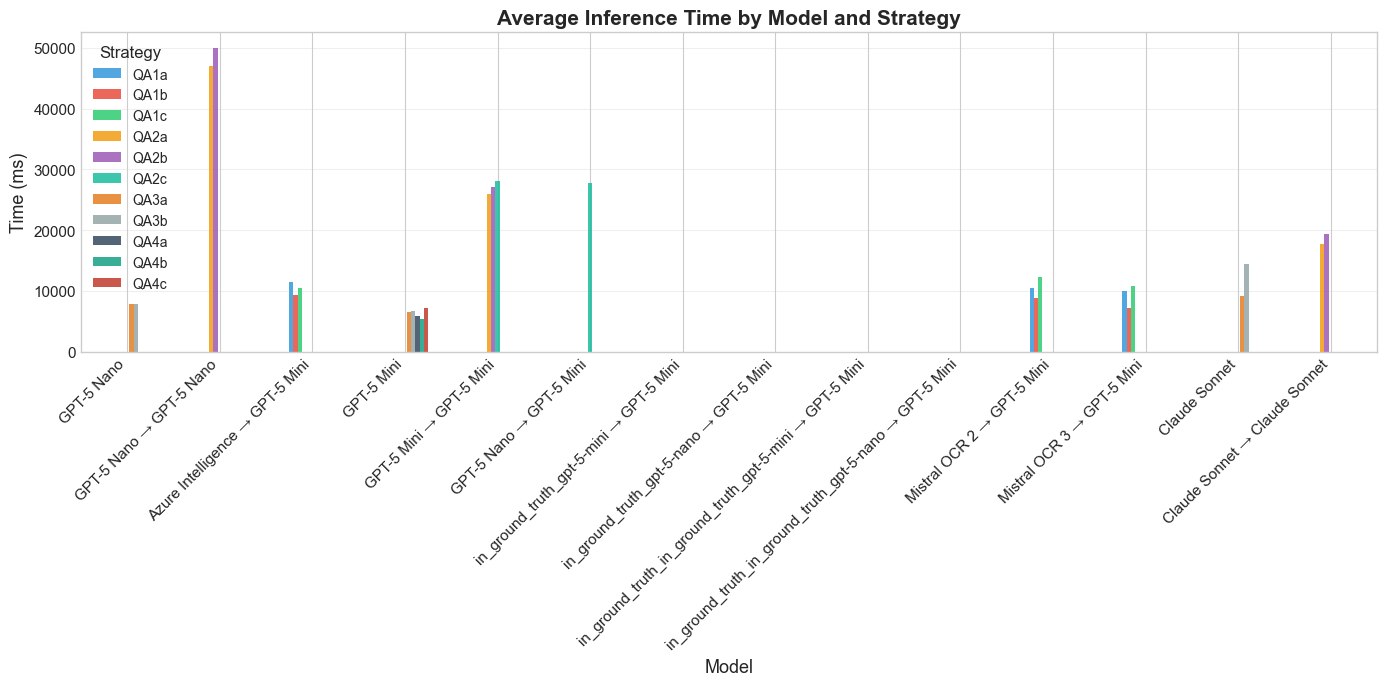

KeyError: "None of [Index(['Strategy', 'Model', 'ANLS'], dtype='object')] are in the [columns]"

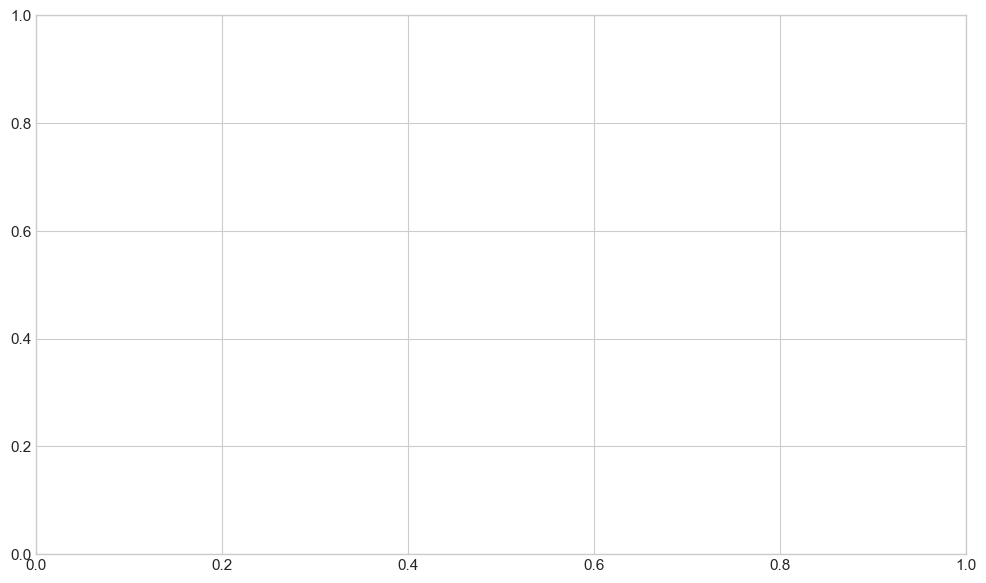

In [ ]:
speed_accuracy = pd.merge(
    inference_df[['Strategy', 'Model', 'Mean Time (ms)']],
    summary_df[['Strategy', 'Model', 'ANLS']],
    on=['Strategy', 'Model']
)


## 15. InfographicVQA-Specific Analysis

Analyze infographic-specific patterns: chart types, visual reasoning vs text extraction, and QA4 special strategy comparison.

In [ ]:
# Analyze performance on infographic-specific patterns
print("\nInfographicVQA-Specific Analysis:")
print("=" * 100)
print("\nKey Findings:")
print("- Infographic questions involve charts, statistics, and visual design elements")
print("- Questions require both text extraction and visual reasoning")
print("- Chart types may include bar charts, pie charts, line graphs, and infographic layouts")
print("\nQA4 Special Strategy Comparison:")

# Compare QA4 with other strategies
if 'QA4a' in summary_df['Phase'].values or 'QA4b' in summary_df['Phase'].values or 'QA4c' in summary_df['Phase'].values:
    qa4_data = summary_df[summary_df['Phase'].str.startswith('QA4')]
    other_data = summary_df[~summary_df['Phase'].str.startswith('QA4')]
    
    print(f"\nQA4 Strategy Performance:")
    print(f"  Average GT in Pred: {qa4_data['GT in Pred'].mean():.4f} [PRIMARY]")
    print(f"  Average ANLS: {qa4_data['ANLS'].mean():.4f}")
    print(f"  Average Exact Match: {qa4_data['Exact Match'].mean():.4f}")
    
    print(f"\nOther Strategies (QA1-QA3) Performance:")
    print(f"  Average GT in Pred: {other_data['GT in Pred'].mean():.4f} [PRIMARY]")
    print(f"  Average ANLS: {other_data['ANLS'].mean():.4f}")
    print(f"  Average Exact Match: {other_data['Exact Match'].mean():.4f}")
    
    improvement = ((qa4_data['GT in Pred'].mean() - other_data['GT in Pred'].mean()) / other_data['GT in Pred'].mean()) * 100
    print(f"\n🎯 QA4 vs Others (GT in Pred): {improvement:+.1f}% {'improvement' if improvement > 0 else 'decline'}")
else:
    print("  No QA4 data available for comparison")

print("\nRecommendations for infographic QA:")
print("- Direct VQA (QA3) may excel at visual reasoning questions")
print("- OCR pipeline (QA1) can be effective for text-heavy infographics")
print("- Consider QA4 special strategy for complex chart understanding")
print("- Evaluate model performance on different chart types if metadata available")


InfographicVQA-Specific Analysis:

Key Findings:
- Infographic questions involve charts, statistics, and visual design elements
- Questions require both text extraction and visual reasoning
- Chart types may include bar charts, pie charts, line graphs, and infographic layouts

QA4 Special Strategy Comparison:

QA4 Strategy Performance:
  Average GT in Pred: 0.5808 [PRIMARY]
  Average ANLS: 0.4912
  Average Exact Match: 0.4014

Other Strategies (QA1-QA3) Performance:
  Average GT in Pred: 0.4840 [PRIMARY]
  Average ANLS: 0.2919
  Average Exact Match: 0.2277

🎯 QA4 vs Others (GT in Pred): +20.0% improvement

Recommendations for infographic QA:
- Direct VQA (QA3) may excel at visual reasoning questions
- OCR pipeline (QA1) can be effective for text-heavy infographics
- Consider QA4 special strategy for complex chart understanding
- Evaluate model performance on different chart types if metadata available


In [ ]:
# Analyze inference times and create Speed vs Accuracy scatter plot
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    # Add strategy column
    inference_df['Strategy'] = inference_df['Phase'].apply(get_phase_strategy)
    
    # Merge inference time with GT in Pred scores (PRIMARY METRIC)
    speed_accuracy = pd.merge(
        inference_df[['Phase', 'Model', 'Mean Time (ms)', 'Strategy']],
        summary_df[['Phase', 'Model', 'GT in Pred']],
        on=['Phase', 'Model'],
        how='inner'
    )
    
    if len(speed_accuracy) > 0:
        # Speed vs Accuracy scatter plot grouped by strategy
        fig, ax = plt.subplots(figsize=(14, 8))
        
        colors_map = {
            '$QA_{\\text{OCR}}$': '#3498db',
            '$QA_{\\text{VLM-2stage}}$': '#e74c3c',
            '$QA_{\\text{VLM-direct}}$': '#2ecc71',
            '$QA_{\\text{special}}$': '#f39c12'
        }
        
        for strategy in sorted(speed_accuracy['Strategy'].unique()):
            strategy_data = speed_accuracy[speed_accuracy['Strategy'] == strategy]
            ax.scatter(strategy_data['Mean Time (ms)'], strategy_data['GT in Pred'], 
                      s=200, alpha=0.7, label=strategy, color=colors_map.get(strategy, '#95a5a6'))
        
        ax.set_title('🎯 Speed vs Accuracy Trade-off (GT in Pred - PRIMARY METRIC)', 
                    fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel('Average Inference Time (ms)', fontsize=13)
        ax.set_ylabel('GT in Pred Score', fontsize=13)
        ax.legend(title='QA Strategy', loc='best', fontsize=11, title_fontsize=12)
        ax.grid(alpha=0.3, linestyle='--')
        ax.set_ylim(-0.05, 1.05)
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*120)
        print("Speed vs Accuracy Analysis (GT in Pred - PRIMARY METRIC)")
        print("="*120)
        display(speed_accuracy.sort_values(['Strategy', 'GT in Pred'], ascending=[True, False]))
    else:
        print("No matching data for speed vs accuracy analysis")
else:
    print("No inference time data available")

KeyError: "None of [Index(['Phase', 'Model', 'GT in Pred'], dtype='object')] are in the [columns]"


Inference Time Summary:



Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms),Strategy
2,QA1a,mistral_ocr_3__gpt-5-mini,9986.507437,9450.701118,$QA_{\text{OCR}}$
1,QA1a,mistral_document_ai__gpt-5-mini,10401.340370,9317.458868,$QA_{\text{OCR}}$
0,QA1a,azure_intelligence__gpt-5-mini,11438.414013,9392.899156,$QA_{\text{OCR}}$
5,QA1b,mistral_ocr_3__gpt-5-mini,7176.615162,6458.381414,$QA_{\text{OCR}}$
4,QA1b,mistral_document_ai__gpt-5-mini,8741.683615,7225.490332,$QA_{\text{OCR}}$
3,QA1b,azure_intelligence__gpt-5-mini,9328.025235,8146.299958,$QA_{\text{OCR}}$
6,QA1c,azure_intelligence__gpt-5-mini,10418.750820,9160.004377,$QA_{\text{OCR}}$
8,QA1c,mistral_ocr_3__gpt-5-mini,10800.276764,10126.909494,$QA_{\text{OCR}}$
7,QA1c,mistral_document_ai__gpt-5-mini,12306.591010,10879.001021,$QA_{\text{OCR}}$
9,QA2a,claude_sonnet__claude_sonnet,17677.348289,16751.580000,$QA_{\text{VLM-2stage}}$



Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms),Strategy
2,QA1a,mistral_ocr_3__gpt-5-mini,9986.507437,9450.701118,$QA_{\text{OCR}}$
1,QA1a,mistral_document_ai__gpt-5-mini,10401.340370,9317.458868,$QA_{\text{OCR}}$
0,QA1a,azure_intelligence__gpt-5-mini,11438.414013,9392.899156,$QA_{\text{OCR}}$
5,QA1b,mistral_ocr_3__gpt-5-mini,7176.615162,6458.381414,$QA_{\text{OCR}}$
4,QA1b,mistral_document_ai__gpt-5-mini,8741.683615,7225.490332,$QA_{\text{OCR}}$
3,QA1b,azure_intelligence__gpt-5-mini,9328.025235,8146.299958,$QA_{\text{OCR}}$
6,QA1c,azure_intelligence__gpt-5-mini,10418.750820,9160.004377,$QA_{\text{OCR}}$
8,QA1c,mistral_ocr_3__gpt-5-mini,10800.276764,10126.909494,$QA_{\text{OCR}}$
7,QA1c,mistral_document_ai__gpt-5-mini,12306.591010,10879.001021,$QA_{\text{OCR}}$
9,QA2a,claude_sonnet__claude_sonnet,17677.348289,16751.580000,$QA_{\text{VLM-2stage}}$


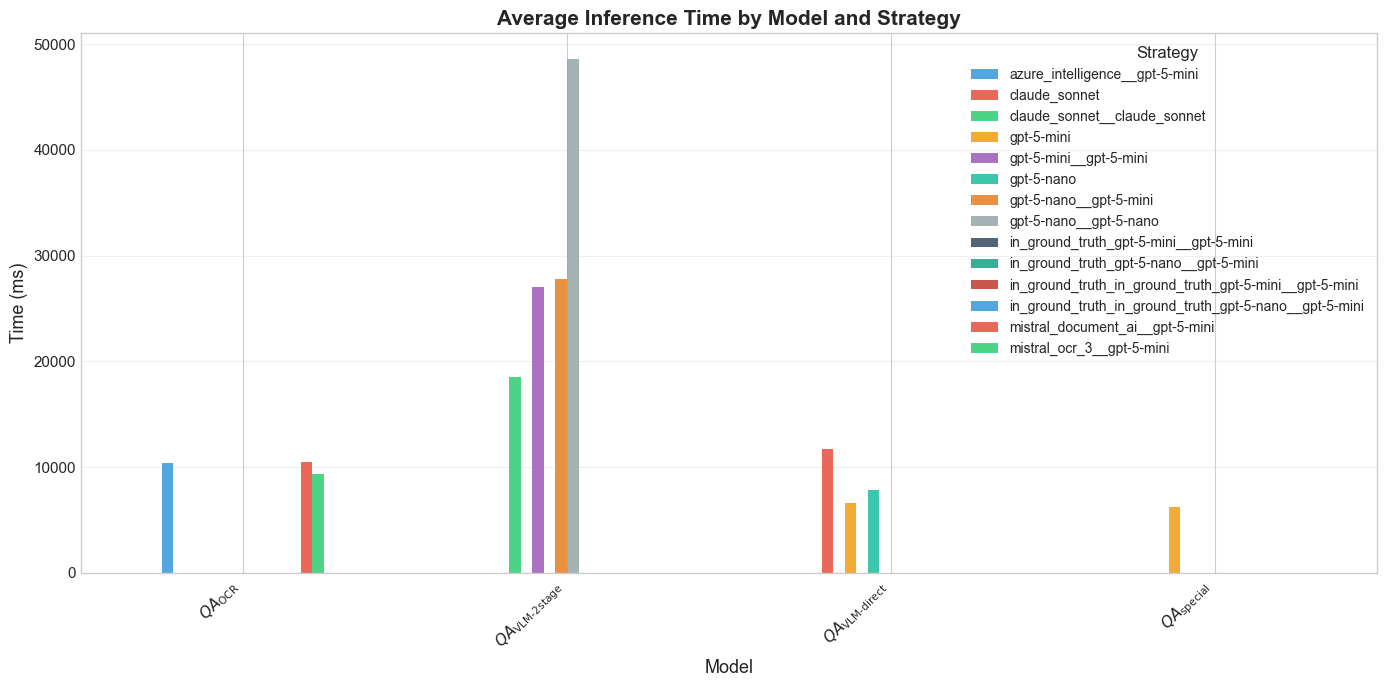


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms),Strategy
2,QA1a,mistral_ocr_3__gpt-5-mini,9986.507437,9450.701118,$QA_{\text{OCR}}$
1,QA1a,mistral_document_ai__gpt-5-mini,10401.340370,9317.458868,$QA_{\text{OCR}}$
0,QA1a,azure_intelligence__gpt-5-mini,11438.414013,9392.899156,$QA_{\text{OCR}}$
5,QA1b,mistral_ocr_3__gpt-5-mini,7176.615162,6458.381414,$QA_{\text{OCR}}$
4,QA1b,mistral_document_ai__gpt-5-mini,8741.683615,7225.490332,$QA_{\text{OCR}}$
3,QA1b,azure_intelligence__gpt-5-mini,9328.025235,8146.299958,$QA_{\text{OCR}}$
6,QA1c,azure_intelligence__gpt-5-mini,10418.750820,9160.004377,$QA_{\text{OCR}}$
8,QA1c,mistral_ocr_3__gpt-5-mini,10800.276764,10126.909494,$QA_{\text{OCR}}$
7,QA1c,mistral_document_ai__gpt-5-mini,12306.591010,10879.001021,$QA_{\text{OCR}}$
9,QA2a,claude_sonnet__claude_sonnet,17677.348289,16751.580000,$QA_{\text{VLM-2stage}}$


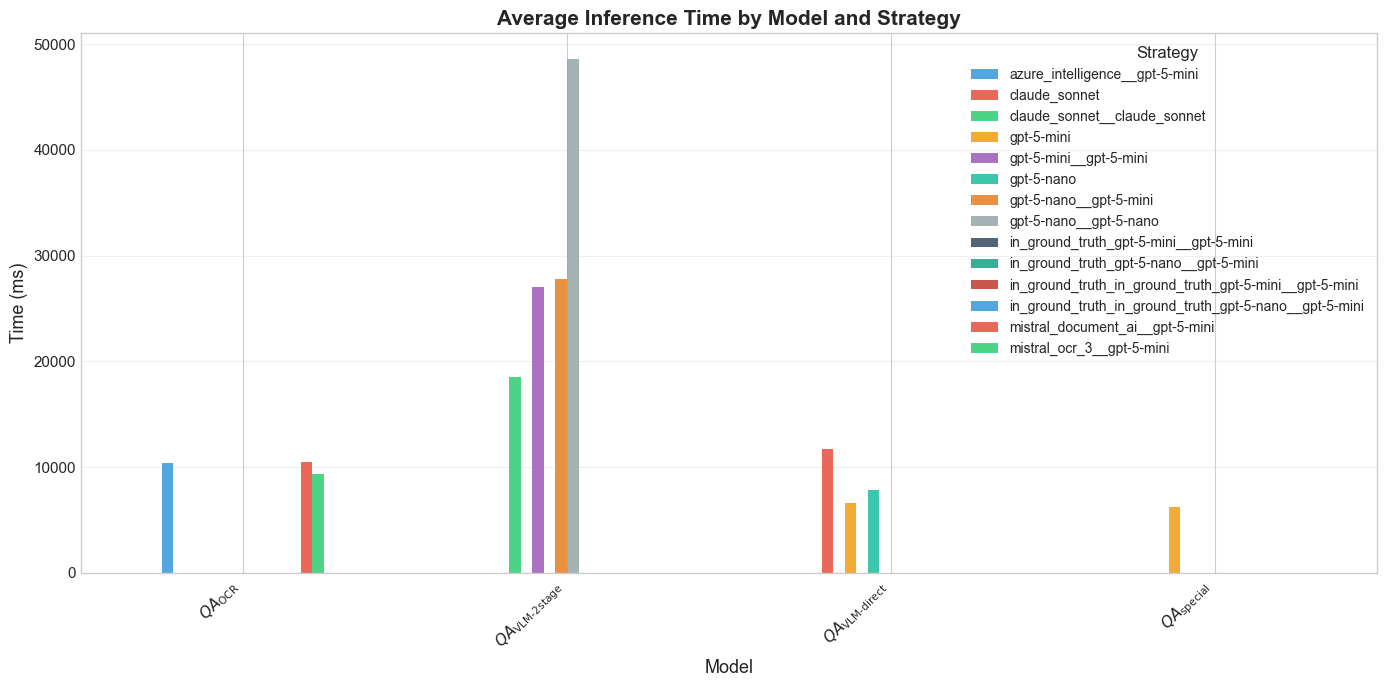

KeyError: "None of [Index(['Strategy', 'Model', 'GT in Pred'], dtype='object')] are in the [columns]"


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms),Strategy
2,QA1a,mistral_ocr_3__gpt-5-mini,9986.507437,9450.701118,$QA_{\text{OCR}}$
1,QA1a,mistral_document_ai__gpt-5-mini,10401.340370,9317.458868,$QA_{\text{OCR}}$
0,QA1a,azure_intelligence__gpt-5-mini,11438.414013,9392.899156,$QA_{\text{OCR}}$
5,QA1b,mistral_ocr_3__gpt-5-mini,7176.615162,6458.381414,$QA_{\text{OCR}}$
4,QA1b,mistral_document_ai__gpt-5-mini,8741.683615,7225.490332,$QA_{\text{OCR}}$
3,QA1b,azure_intelligence__gpt-5-mini,9328.025235,8146.299958,$QA_{\text{OCR}}$
6,QA1c,azure_intelligence__gpt-5-mini,10418.750820,9160.004377,$QA_{\text{OCR}}$
8,QA1c,mistral_ocr_3__gpt-5-mini,10800.276764,10126.909494,$QA_{\text{OCR}}$
7,QA1c,mistral_document_ai__gpt-5-mini,12306.591010,10879.001021,$QA_{\text{OCR}}$
9,QA2a,claude_sonnet__claude_sonnet,17677.348289,16751.580000,$QA_{\text{VLM-2stage}}$


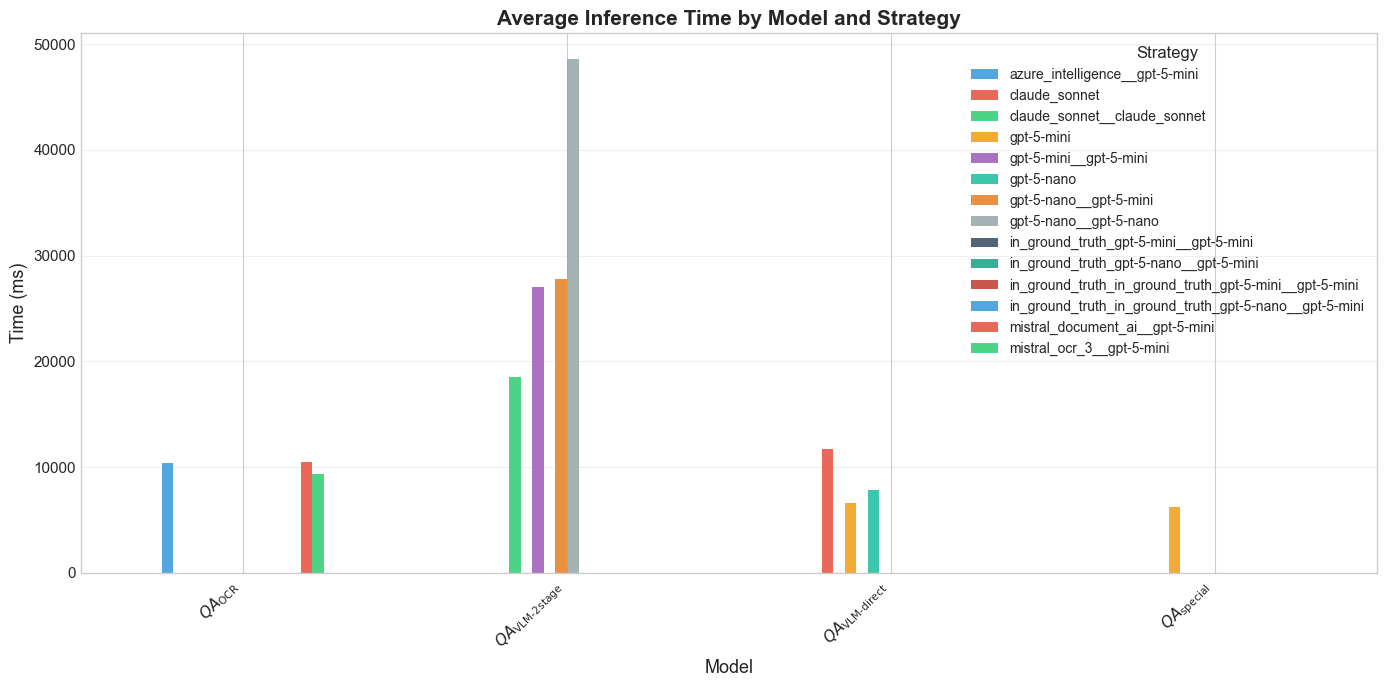

KeyError: "None of [Index(['Strategy', 'Model', 'GT in Pred'], dtype='object')] are in the [columns]"

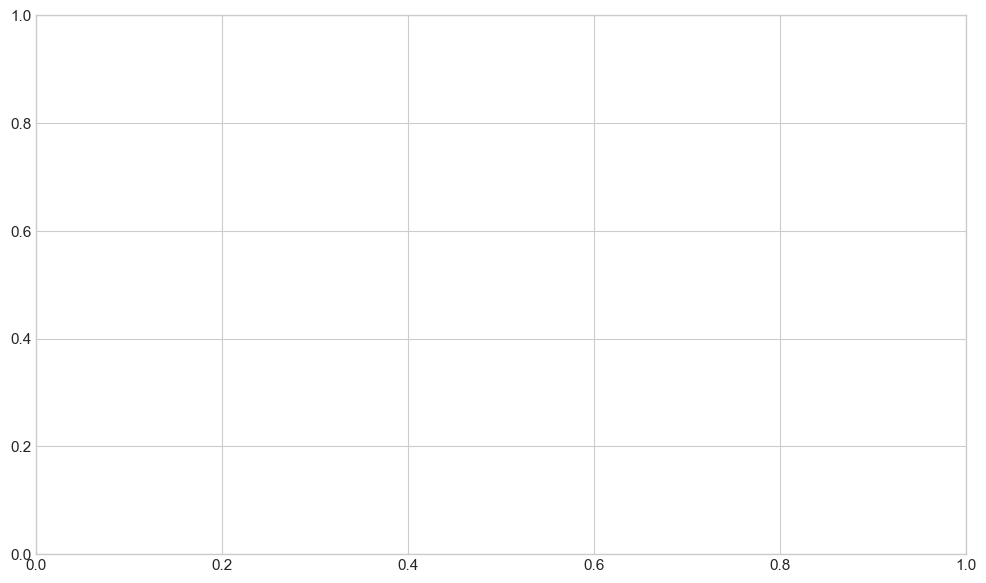

In [ ]:
in the# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    # Add strategy column
    inference_df['Strategy'] = inference_df['Phase'].apply(get_phase_strategy)
    
    print("\nInference Time Summary:")
    print("="*120)
    display(inference_df.sort_values(['Phase', 'Mean Time (ms)']))
    
    # Visualization - aggregate by strategy
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Aggregate by strategy
    strategy_time = inference_df.groupby(['Strategy', 'Model'])['Mean Time (ms)'].mean().unstack()
    strategy_time = strategy_time.reindex(sort_models(strategy_time.index.tolist()))
    strategy_time.plot(kind='bar', ax=ax, color=colors_palette[:len(strategy_time.columns)], alpha=0.85)
    
    ax.set_title('Average Inference Time by Model and Strategy', fontsize=15, fontweight='bold')
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel('Time (ms)', fontsize=13)
    ax.legend(title='Strategy', title_fontsize=12, fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], 
                       rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Speed vs Accuracy scatter plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Merge inference time with GT in Pred scores (PRIMARY METRIC)
    speed_accuracy = pd.merge(
        inference_df[['Strategy', 'Model', 'Mean Time (ms)']],
        summary_df[['Strategy', 'Model', 'GT in Pred']],
        on=['Strategy', 'Model']
    )
    
    for strategy in speed_accuracy['Strategy'].unique():
        strategy_data = speed_accuracy[speed_accuracy['Strategy'] == strategy]
        ax.scatter(strategy_data['Mean Time (ms)'], strategy_data['GT in Pred'], 
                  s=150, alpha=0.7, label=strategy)
    
    ax.set_title('🎯 Speed vs Accuracy Trade-off (GT in Pred - PRIMARY METRIC)', fontsize=15, fontweight='bold')
    ax.set_xlabel('Average Inference Time (ms)', fontsize=13)
    ax.set_ylabel('GT in Pred Score', fontsize=13)
    ax.legend(title='Strategy', loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 17. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [ ]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
Saving embeddings for modified phases: {'QA1b', 'QA1a', 'QA1c'}
✅ Saved: QA1b_embeddings_text-embedding-3-large_20260204_114406.json
✅ Saved: QA1a_embeddings_text-embedding-3-large_20260204_114411.json
✅ Saved: QA1c_embeddings_text-embedding-3-large_20260204_114415.json

✅ All embeddings have been persisted to disk!
